# Home Cage 2-Minute Social Proximity DA

This notebook summarizes Home Cage dopamine during automated social proximity frames, instead of manual investigation annotations, within the first 120 seconds of each agent bout.

In [1]:
import os
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))

from bouts_extension import plot_behavior_across_bouts_no_identities


In [2]:
from IPython.display import display

POSE_DA_PATH = PROJECT_ROOT / 'Pose_Tracking' / 'home_cage_pose_DA_all.csv'

REGION_CONFIGS = {
    'NAc': {'color': '#15616F', 'ylim': (-3, 3)},
    'mPFC': {'color': '#FFAF00', 'ylim': (-3, 3)},
}

BOUT_ORDER = ['Short_Term-1', 'Short_Term-2', 'Long_Term-1', 'Novel-1']
XTICK_LABELS = ['Acq-ST', 'Short-T', 'Long-T', 'Novel']
XTICK_COLORS = ['#2A9D8F', '#457B9D', '#7B2CBF', '#E76F51']

SIGNAL_COLUMN = 'Mean Z-score'
RAW_SIGNAL_COLUMN = 'zscore_DA'
WINDOW_CAP_S = 120
YTICKS_INCREMENT = 1

ANALYSIS_ORDER = ['first_2min', 'full_bout', 'first_social_instance', 'first_subject_initiated_social_instance']
ANALYSIS_LABELS = {
    'first_2min': 'First 2 min',
    'full_bout': 'Full Bout',
    'first_social_instance': 'First Social Proximity Instance',
    'first_subject_initiated_social_instance': 'First Subject-Initiated Social Proximity Instance',
}

BEHAVIOR_ORDER = [
    'full_bout',
    'social_any',
    'anogenital_sniff',
    'facial_sniff',
    'non_social',
    'agent_in_subject_only',
    'subject_in_agent_only',
    'subject_in_agent_with_both',
]

BEHAVIOR_LABELS = {
    'full_bout': 'Full Bout Mean',
    'social_any': 'Any Social Proximity Mean',
    'anogenital_sniff': 'Anogenital Sniff Mean',
    'facial_sniff': 'Facial Sniff Mean',
    'non_social': 'Non-Social Mean',
    'agent_in_subject_only': 'Agent in Subject Only',
    'subject_in_agent_only': 'Subject in Agent Only',
    'subject_in_agent_with_both': 'Subject in Agent + Both',
}

In [3]:
def load_pose_da_frame(csv_path):
    usecols = [
        'time_s',
        'brain_region',
        'mouse_identity',
        'zscore_DA',
        'intruder_identity',
        'agent_in_subject',
        'subject_in_agent',
        'distance_head_res__head_int',
        'distance_head_res__hind_int',
    ]
    df = pd.read_csv(csv_path, usecols=usecols)
    df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
    df[RAW_SIGNAL_COLUMN] = pd.to_numeric(df[RAW_SIGNAL_COLUMN], errors='coerce')
    df['distance_head_res__head_int'] = pd.to_numeric(df['distance_head_res__head_int'], errors='coerce')
    df['distance_head_res__hind_int'] = pd.to_numeric(df['distance_head_res__hind_int'], errors='coerce')
    df = df.dropna(subset=['time_s', RAW_SIGNAL_COLUMN]).copy()

    df['Subject'] = df['mouse_identity'].astype(str).str.strip()
    df['BrainRegion'] = df['brain_region'].astype(str).str.strip()
    df['Bout'] = df['intruder_identity'].astype(str).str.strip()

    df = df[df['Bout'].isin(BOUT_ORDER)].copy()
    df['agent_in_subject_yes'] = df['agent_in_subject'].eq('Yes')
    df['subject_in_agent_yes'] = df['subject_in_agent'].eq('Yes')

    df['social_any'] = df['agent_in_subject_yes'] | df['subject_in_agent_yes']
    df['both_yes'] = df['agent_in_subject_yes'] & df['subject_in_agent_yes']

    df['agent_in_subject_only'] = df['agent_in_subject_yes'] & ~df['subject_in_agent_yes']
    df['subject_in_agent_only'] = df['subject_in_agent_yes'] & ~df['agent_in_subject_yes']
    df['subject_in_agent_with_both'] = df['subject_in_agent_yes']
    # Proxy anogenital sniffing as subject-in-agent frames where the
    # subject head is closer to the agent hind than the agent head.
    df['anogenital_sniff'] = (
        df['subject_in_agent_yes']
        & df['distance_head_res__hind_int'].notna()
        & df['distance_head_res__head_int'].notna()
        & (df['distance_head_res__hind_int'] < df['distance_head_res__head_int'])
    )
    # Proxy facial sniffing as subject-in-agent frames where the
    # subject head is closer to the agent head than the agent hind.
    df['facial_sniff'] = (
        df['subject_in_agent_yes']
        & df['distance_head_res__hind_int'].notna()
        & df['distance_head_res__head_int'].notna()
        & (df['distance_head_res__head_int'] <= df['distance_head_res__hind_int'])
    )

    # df['agent_in_subject_yes'] = df['agent_in_subject'].eq('Yes')
    # df['subject_in_agent_yes'] = df['subject_in_agent'].eq('Yes')

    # df['social_any'] = df['agent_in_subject_yes'] | df['subject_in_agent_yes']
    # df['both_yes'] = df['agent_in_subject_yes'] & df['subject_in_agent_yes']

    # # Exclusive agent_in_subject only
    # df['agent_in_subject_only'] = df['agent_in_subject_yes'] & ~df['subject_in_agent_yes']

    # # subject_in_agent inclusive of both
    # df['subject_in_agent_with_both'] = df['subject_in_agent_yes']

    return df.sort_values(['BrainRegion', 'Subject', 'Bout', 'time_s']).reset_index(drop=True)


def mean_and_count(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return np.nan, 0
    return float(values.mean()), int(values.size)


def first_true_block_mask(mask):
    mask = mask.fillna(False).astype(bool)
    values = mask.to_numpy()
    true_idx = np.flatnonzero(values)
    out = np.zeros(len(values), dtype=bool)
    if len(true_idx) == 0:
        return pd.Series(out, index=mask.index)

    start = true_idx[0]
    end = start
    while end + 1 < len(values) and values[end + 1]:
        end += 1
    out[start:end + 1] = True
    return pd.Series(out, index=mask.index)


def classify_first_instance(first_block):
    if first_block.empty:
        return 'none'
    first_row = first_block.iloc[0]
    if bool(first_row['both_yes']):
        return 'both'
    if bool(first_row['agent_in_subject_only']):
        return 'agent_in_subject_only'
    if bool(first_row['subject_in_agent_only']):
        return 'subject_in_agent_only'
    return 'unclassified'


def build_social_metadata(df):
    rows = []
    notes = []

    for (region_name, subject_name, bout_name), rec in df.groupby(['BrainRegion', 'Subject', 'Bout'], sort=False):
        rec = rec.sort_values('time_s').copy()
        bout_start = float(rec['time_s'].min())

        first_instance_mask = first_true_block_mask(rec['social_any'])
        first_instance = rec.loc[first_instance_mask].copy()
        first_subject_initiated_instance_mask = first_true_block_mask(rec['subject_in_agent_yes'])
        first_subject_initiated_instance = rec.loc[first_subject_initiated_instance_mask].copy()

        notes.append(
            {
                'BrainRegion': region_name,
                'Subject': subject_name,
                'Bout': bout_name,
                'FirstInstanceFound': not first_instance.empty,
                'FirstInstanceStart_s': float(first_instance['time_s'].min()) if not first_instance.empty else np.nan,
                'FirstInstanceEnd_s': float(first_instance['time_s'].max()) if not first_instance.empty else np.nan,
                'FirstInstanceNFrames': int(len(first_instance)),
                'FirstSubjectInitiatedInstanceFound': not first_subject_initiated_instance.empty,
                'FirstSubjectInitiatedInstanceStart_s': float(first_subject_initiated_instance['time_s'].min()) if not first_subject_initiated_instance.empty else np.nan,
                'FirstSubjectInitiatedInstanceEnd_s': float(first_subject_initiated_instance['time_s'].max()) if not first_subject_initiated_instance.empty else np.nan,
                'FirstSubjectInitiatedInstanceNFrames': int(len(first_subject_initiated_instance)),
                'FirstInstanceHasBoth': bool(first_instance['both_yes'].any()) if not first_instance.empty else False,
                'FirstInstanceHasAnogenital': bool(first_instance['anogenital_sniff'].any()) if not first_instance.empty else False,
                'FirstInstanceHasFacial': bool(first_instance['facial_sniff'].any()) if not first_instance.empty else False,
                'FirstInstanceType': classify_first_instance(first_instance),
                'FirstSubjectInitiatedInstanceHasBoth': bool(first_subject_initiated_instance['both_yes'].any()) if not first_subject_initiated_instance.empty else False,
                'FirstSubjectInitiatedInstanceHasAnogenital': bool(first_subject_initiated_instance['anogenital_sniff'].any()) if not first_subject_initiated_instance.empty else False,
                'FirstSubjectInitiatedInstanceHasFacial': bool(first_subject_initiated_instance['facial_sniff'].any()) if not first_subject_initiated_instance.empty else False,
                'FirstSubjectInitiatedInstanceType': classify_first_instance(first_subject_initiated_instance),
            }
        )

        analysis_frames = {
            'first_2min': rec.loc[rec['time_s'] <= bout_start + WINDOW_CAP_S].copy(),
            'full_bout': rec.copy(),
            'first_social_instance': first_instance.copy(),
            'first_subject_initiated_social_instance': first_subject_initiated_instance.copy(),
        }

        for analysis_name, sub in analysis_frames.items():
            masks = {
                'full_bout': pd.Series(True, index=sub.index),
                'social_any': sub['social_any'] if not sub.empty else pd.Series(dtype=bool),
                'anogenital_sniff': sub['anogenital_sniff'] if not sub.empty else pd.Series(dtype=bool),
                'facial_sniff': sub['facial_sniff'] if not sub.empty else pd.Series(dtype=bool),
                'non_social': (~sub['social_any']) if not sub.empty else pd.Series(dtype=bool),
                'agent_in_subject_only': sub['agent_in_subject_only'] if not sub.empty else pd.Series(dtype=bool),
                'subject_in_agent_only': sub['subject_in_agent_only'] if not sub.empty else pd.Series(dtype=bool),
                'subject_in_agent_with_both': sub['subject_in_agent_with_both'] if not sub.empty else pd.Series(dtype=bool),
            }

            for behavior_name in BEHAVIOR_ORDER:
                mask = masks[behavior_name]
                values = sub.loc[mask, RAW_SIGNAL_COLUMN] if not sub.empty else pd.Series(dtype=float)
                mean_signal, n_samples = mean_and_count(values)

                rows.append(
                    {
                        'BrainRegion': region_name,
                        'Subject': subject_name,
                        'Bout': bout_name,
                        'Analysis': analysis_name,
                        'AnalysisLabel': ANALYSIS_LABELS[analysis_name],
                        'Behavior': behavior_name,
                        'BehaviorLabel': BEHAVIOR_LABELS[behavior_name],
                        SIGNAL_COLUMN: mean_signal,
                        'N_Samples': n_samples,
                        'Window_Duration_s': float(n_samples) / 10.0,
                    }
                )

    metadata_df = pd.DataFrame(rows)
    metadata_df['Bout'] = pd.Categorical(metadata_df['Bout'], categories=BOUT_ORDER, ordered=True)
    metadata_df['Analysis'] = pd.Categorical(metadata_df['Analysis'], categories=ANALYSIS_ORDER, ordered=True)
    metadata_df['Behavior'] = pd.Categorical(metadata_df['Behavior'], categories=BEHAVIOR_ORDER, ordered=True)

    notes_df = pd.DataFrame(notes).sort_values(['BrainRegion', 'Bout', 'Subject']).reset_index(drop=True)
    metadata_df = metadata_df.sort_values(['BrainRegion', 'Analysis', 'Behavior', 'Bout', 'Subject']).reset_index(drop=True)
    return metadata_df, notes_df


def get_region_color(region_name):
    return REGION_CONFIGS.get(region_name, {'color': '#4C4C4C'})['color']


def get_region_ylim(region_name):
    return REGION_CONFIGS.get(region_name, {'ylim': (-3, 3)})['ylim']


def get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name):
    plot_df = metadata_df[
        (metadata_df['BrainRegion'] == region_name)
        & (metadata_df['Analysis'] == analysis_name)
        & (metadata_df['Behavior'] == behavior_name)
    ].copy()
    return plot_df.pivot(index='Subject', columns='Bout', values=SIGNAL_COLUMN).reindex(columns=BOUT_ORDER)


def compute_auto_ylim(pivot_df, pad=0.2, min_range=1.0):
    values = pivot_df.to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return (-1, 1)

    ymin = float(values.min())
    ymax = float(values.max())

    if ymin == ymax:
        half = max(abs(ymin) * 0.25, min_range / 2)
        return (ymin - half, ymax + half)

    yrange = ymax - ymin
    pad_amt = max(yrange * pad, 0.1)
    ymin -= pad_amt
    ymax += pad_amt

    center_zero = max(abs(ymin), abs(ymax))
    return (-center_zero, center_zero)


MANUAL_YLIMS = {
    # Example:
    ('NAc', 'first_social_instance', 'subject_in_agent_with_both'): (-2, 7),
    # ('mPFC', 'full_bout', 'subject_in_agent_with_both'): (-1, 1),
}


def resolve_ylim(region_name, analysis_name=None, behavior_name=None, pivot_df=None, auto_ylim=True):
    key = (region_name, analysis_name, behavior_name)

    if key in MANUAL_YLIMS:
        return MANUAL_YLIMS[key]

    if auto_ylim and pivot_df is not None:
        return compute_auto_ylim(pivot_df)

    return get_region_ylim(region_name)


def plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='social_any', auto_ylim=True):
    subset = metadata_df[
        (metadata_df['BrainRegion'] == region_name)
        & (metadata_df['Analysis'] == analysis_name)
    ].copy()

    pivot_df = get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name)
    ylim = resolve_ylim(
        region_name,
        analysis_name=analysis_name,
        behavior_name=behavior_name,
        pivot_df=pivot_df,
        auto_ylim=auto_ylim,
    )

    return plot_behavior_across_bouts_no_identities(
        metadata_df=subset,
        y_col=SIGNAL_COLUMN,
        behavior=behavior_name,
        title=f'{region_name} | {BEHAVIOR_LABELS[behavior_name]} | {ANALYSIS_LABELS[analysis_name]}',
        xlabel='Agent',
        ylabel='Mean z-scored dF/F',
        custom_xtick_labels=XTICK_LABELS,
        custom_xtick_colors=XTICK_COLORS,
        ylim=ylim,
        bar_color=get_region_color(region_name),
        yticks_increment=YTICKS_INCREMENT,
        figsize=(12, 7),
        pad_inches=0.1,
        save=False,
    )


def draw_analysis_panel(ax, metadata_df, region_name, analysis_name, behavior_name='social_any', auto_ylim=True):
    pivot_df = get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name)
    x = np.arange(len(BOUT_ORDER))
    color = get_region_color(region_name)

    mean_values = pivot_df.mean()
    sem_values = pivot_df.sem()

    ax.bar(
        x,
        mean_values.values,
        yerr=sem_values.values,
        width=0.68,
        color=color,
        edgecolor='black',
        linewidth=2.5,
        capsize=5,
        error_kw=dict(elinewidth=2.0, capthick=2.0),
        alpha=0.9,
        zorder=3,
    )

    for _, row in pivot_df.iterrows():
        y = row.values.astype(float)
        ax.plot(x, y, color=color, alpha=0.18, linewidth=1.6, zorder=1)
        ax.scatter(x, y, facecolors='white', edgecolors=color, s=45, alpha=0.75, linewidth=1.2, zorder=2)

    ax.set_title(ANALYSIS_LABELS[analysis_name], fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS, fontsize=16)
    for tick, tick_color in zip(ax.get_xticklabels(), XTICK_COLORS):
        tick.set_color(tick_color)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, zorder=0)

    ylim = resolve_ylim(
        region_name,
        analysis_name=analysis_name,
        behavior_name=behavior_name,
        pivot_df=pivot_df,
        auto_ylim=auto_ylim,
    )
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(np.floor(ylim[0]), np.ceil(ylim[1]) + YTICKS_INCREMENT, YTICKS_INCREMENT))

    ax.tick_params(axis='y', labelsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['bottom'].set_linewidth(2.5)


def plot_all_three_analyses(metadata_df, region_name, behavior_name='social_any', auto_ylim=True):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

    for ax, analysis_name in zip(axes, ANALYSIS_ORDER):
        draw_analysis_panel(
            ax,
            metadata_df,
            region_name,
            analysis_name,
            behavior_name=behavior_name,
            auto_ylim=auto_ylim,
        )
        ax.set_xlabel('Agent', fontsize=16)

    axes[0].set_ylabel('Mean z-scored dF/F', fontsize=18)
    fig.suptitle(f'{region_name} | {BEHAVIOR_LABELS[behavior_name]}', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [4]:
pose_df = load_pose_da_frame(POSE_DA_PATH)
metadata_df, first_instance_notes_df = build_social_metadata(pose_df)

display(first_instance_notes_df.head())
display(first_instance_notes_df[first_instance_notes_df['FirstInstanceHasBoth']].head(20))

print('Rows where the first social instance contains both directions:')
print(first_instance_notes_df['FirstInstanceHasBoth'].sum())

summary_df = (
    metadata_df.groupby(['BrainRegion', 'Analysis', 'Behavior', 'Bout'], observed=True)[SIGNAL_COLUMN]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'].clip(lower=1))
display(summary_df.head(20))

,BrainRegion,Subject,Bout,FirstInstanceFound,FirstInstanceStart_s,FirstInstanceEnd_s,FirstInstanceNFrames,FirstSubjectInitiatedInstanceFound,FirstSubjectInitiatedInstanceStart_s,FirstSubjectInitiatedInstanceEnd_s,FirstSubjectInitiatedInstanceNFrames,FirstInstanceHasBoth,FirstInstanceHasAnogenital,FirstInstanceHasFacial,FirstInstanceType,FirstSubjectInitiatedInstanceHasBoth,FirstSubjectInitiatedInstanceHasAnogenital,FirstSubjectInitiatedInstanceHasFacial,FirstSubjectInitiatedInstanceType
0,NAc,n5,Long_Term-1,True,1476.4,1480.3,40,True,1476.4,1480.2,39,True,True,True,subject_in_agent_only,True,True,True,subject_in_agent_only
1,NAc,n6,Long_Term-1,True,856.3,857.1,9,True,856.3,857.0,8,True,True,True,both,True,True,True,both
2,NAc,n7,Long_Term-1,True,1166.3,1169.4,32,True,1166.6,1169.4,29,True,True,True,agent_in_subject_only,True,True,True,both
3,NAc,nn1,Long_Term-1,True,1470.9,1473.4,26,True,1470.9,1473.4,26,True,True,True,subject_in_agent_only,True,True,True,subject_in_agent_only
4,NAc,nn2,Long_Term-1,True,1169.0,1170.1,12,True,1169.2,1170.1,10,True,True,True,agent_in_subject_only,True,True,True,both


,BrainRegion,Subject,Bout,FirstInstanceFound,FirstInstanceStart_s,FirstInstanceEnd_s,FirstInstanceNFrames,FirstSubjectInitiatedInstanceFound,FirstSubjectInitiatedInstanceStart_s,FirstSubjectInitiatedInstanceEnd_s,FirstSubjectInitiatedInstanceNFrames,FirstInstanceHasBoth,FirstInstanceHasAnogenital,FirstInstanceHasFacial,FirstInstanceType,FirstSubjectInitiatedInstanceHasBoth,FirstSubjectInitiatedInstanceHasAnogenital,FirstSubjectInitiatedInstanceHasFacial,FirstSubjectInitiatedInstanceType
0,NAc,n5,Long_Term-1,True,1476.4,1480.3,40,True,1476.4,1480.2,39,True,True,True,subject_in_agent_only,True,True,True,subject_in_agent_only
1,NAc,n6,Long_Term-1,True,856.3,857.1,9,True,856.3,857.0,8,True,True,True,both,True,True,True,both
2,NAc,n7,Long_Term-1,True,1166.3,1169.4,32,True,1166.6,1169.4,29,True,True,True,agent_in_subject_only,True,True,True,both
3,NAc,nn1,Long_Term-1,True,1470.9,1473.4,26,True,1470.9,1473.4,26,True,True,True,subject_in_agent_only,True,True,True,subject_in_agent_only
4,NAc,nn2,Long_Term-1,True,1169.0,1170.1,12,True,1169.2,1170.1,10,True,True,True,agent_in_subject_only,True,True,True,both
5,NAc,nn3,Long_Term-1,True,1490.1,1490.7,7,True,1490.1,1490.7,7,True,True,True,both,True,True,True,both
7,NAc,nn5,Long_Term-1,True,1476.4,1480.3,40,True,1476.4,1480.2,39,True,True,True,subject_in_agent_only,True,True,True,subject_in_agent_only
8,NAc,nn6,Long_Term-1,True,1164.5,1165.5,11,True,1164.5,1165.5,11,True,True,True,both,True,True,True,both
9,NAc,nn7,Long_Term-1,True,1478.6,1479.3,8,True,1478.6,1479.1,6,True,True,True,both,True,True,True,both
12,NAc,n6,Novel-1,True,1165.4,1165.5,2,True,1165.4,1165.5,2,True,True,True,both,True,True,True,both


Rows where the first social instance contains both directions:
79


,BrainRegion,Analysis,Behavior,Bout,mean,std,count,sem
0,NAc,first_2min,full_bout,Short_Term-1,0.455813,0.428180,11,0.129101
1,NAc,first_2min,full_bout,Short_Term-2,-0.055271,0.310236,11,0.093540
2,NAc,first_2min,full_bout,Long_Term-1,-0.085310,0.207728,11,0.062632
3,NAc,first_2min,full_bout,Novel-1,0.189093,0.259338,11,0.078193
4,NAc,first_2min,social_any,Short_Term-1,0.840413,0.413813,11,0.124769
5,NAc,first_2min,social_any,Short_Term-2,-0.070553,0.296696,11,0.089457
6,NAc,first_2min,social_any,Long_Term-1,0.125936,0.510873,11,0.154034
7,NAc,first_2min,social_any,Novel-1,0.517698,0.457310,11,0.137884
8,NAc,first_2min,anogenital_sniff,Short_Term-1,0.924636,0.535468,11,0.161450
9,NAc,first_2min,anogenital_sniff,Short_Term-2,-0.055769,0.574764,11,0.173298


In [5]:
MANUAL_YLIMS = {
    # examples:
    # ('NAc', 'first_2min', 'social_any'): (-1.5, 2.0),
    # ('mPFC', 'full_bout', 'agent_in_subject_only'): (-0.8, 1.2),
}


In [6]:
MANUAL_YLIMS = {
    ('NAc', 'first_2min', 'social_any'): (-2, 2.0),
    ('NAc', 'full_bout', 'social_any'): (-2, 2),
    ('NAc', 'first_social_instance', 'social_any'): (-2, 7),
    ('NAc', 'first_social_instance', 'social_any'): (-2, 7),
    # ('mPFC', 'full_bout', 'subject_in_agent_only'): (-1, 1),
}

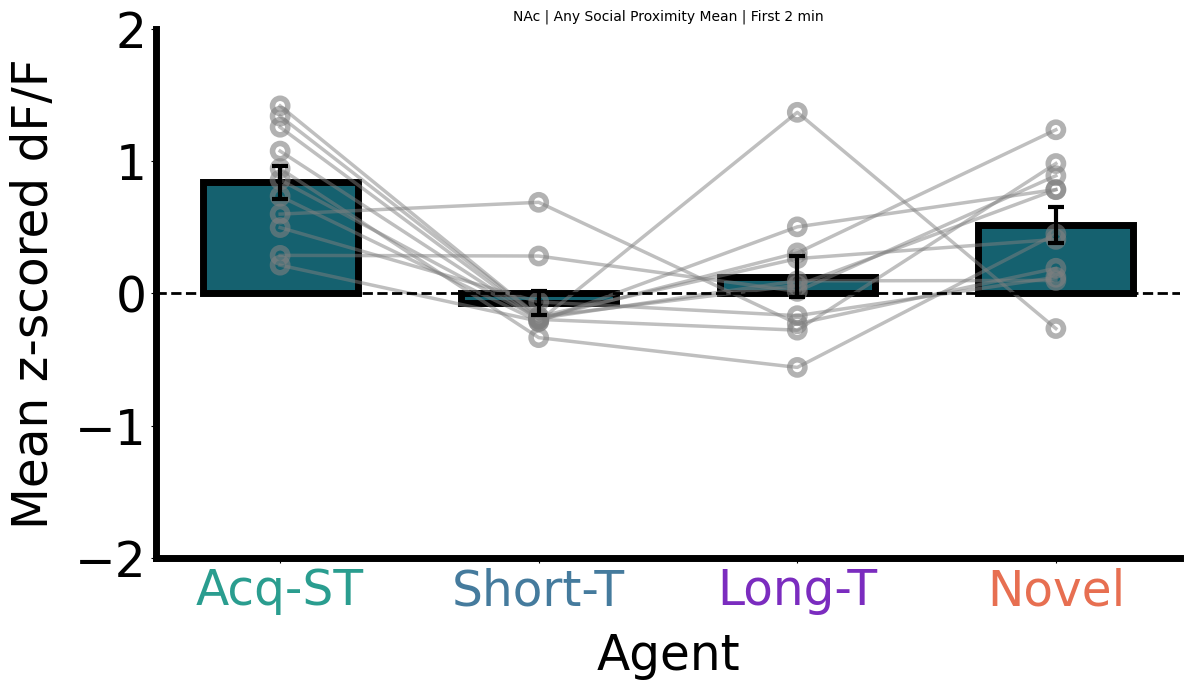


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  5.0387   0.0005   1.5192
 Short_Term-1 vs Long_Term-1 11  3.1782   0.0098   0.9583
     Short_Term-1 vs Novel-1 11  2.4383   0.0350   0.7352
 Short_Term-2 vs Long_Term-1 11 -1.0107   0.3360  -0.3047
     Short_Term-2 vs Novel-1 11 -3.4178   0.0066  -1.0305
      Long_Term-1 vs Novel-1 11 -1.6598   0.1279  -0.5004


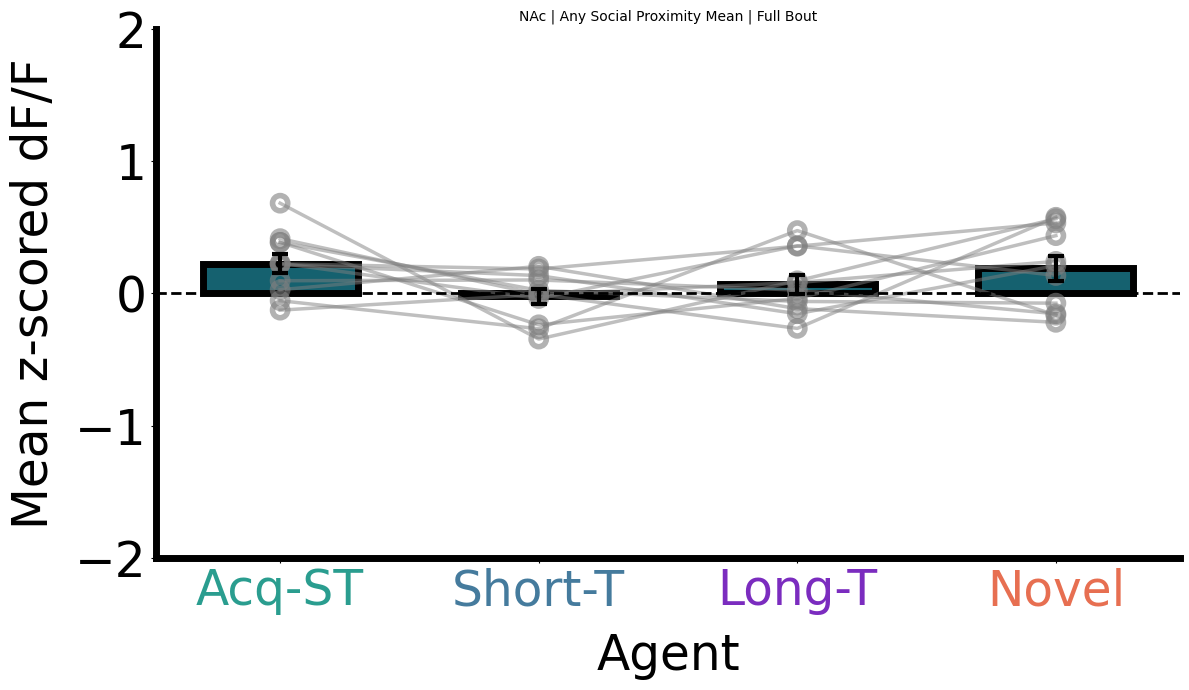


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  2.3400   0.0413   0.7055
 Short_Term-1 vs Long_Term-1 11  1.3662   0.2018   0.4119
     Short_Term-1 vs Novel-1 11  0.4802   0.6414   0.1448
 Short_Term-2 vs Long_Term-1 11 -0.9042   0.3871  -0.2726
     Short_Term-2 vs Novel-1 11 -1.7609   0.1087  -0.5309
      Long_Term-1 vs Novel-1 11 -0.9731   0.3535  -0.2934


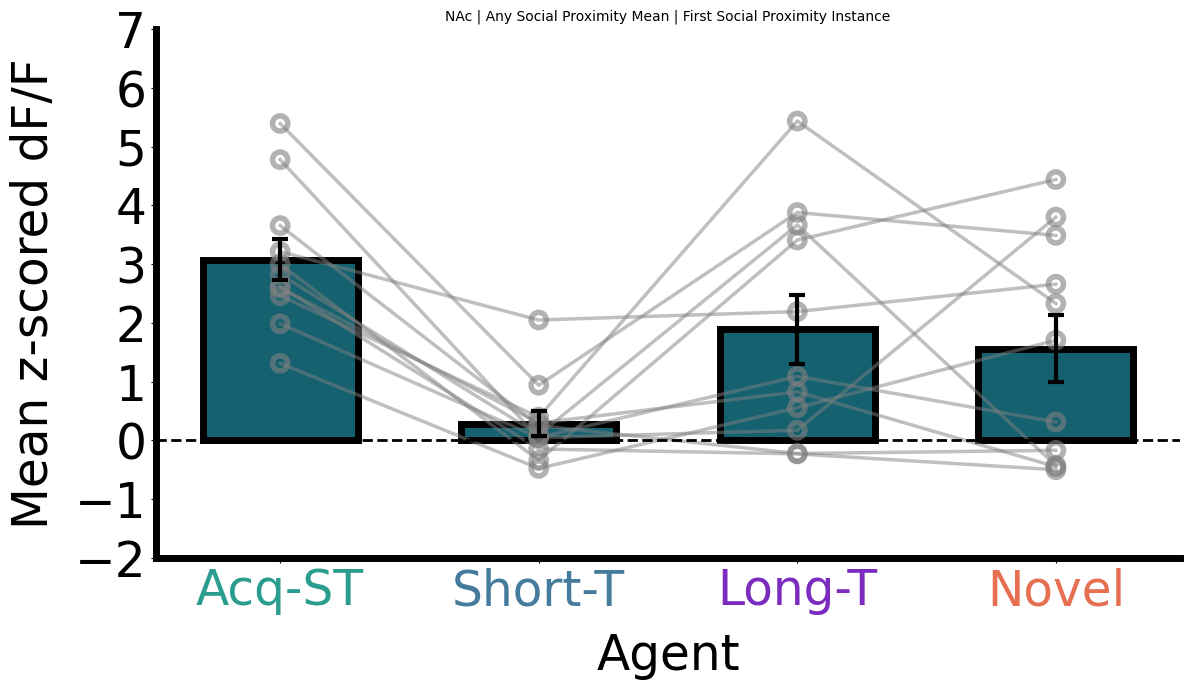


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  8.3243   0.0000   2.5099
 Short_Term-1 vs Long_Term-1 11  1.8299   0.0972   0.5517
     Short_Term-1 vs Novel-1 11  2.9518   0.0145   0.8900
 Short_Term-2 vs Long_Term-1 11 -2.8257   0.0180  -0.8520
     Short_Term-2 vs Novel-1 11 -2.2417   0.0489  -0.6759
      Long_Term-1 vs Novel-1 11  0.5183   0.6156   0.1563


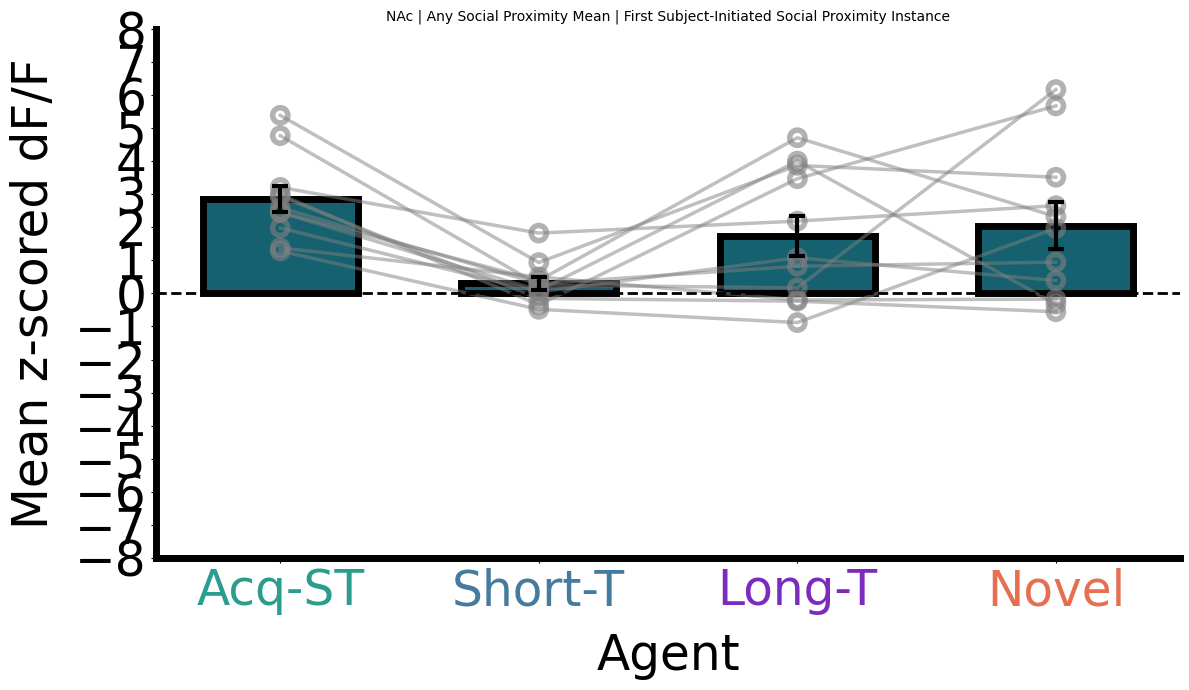


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  7.1912   0.0000   2.1682
 Short_Term-1 vs Long_Term-1 11  1.8917   0.0878   0.5704
     Short_Term-1 vs Novel-1 11  1.4523   0.1771   0.4379
 Short_Term-2 vs Long_Term-1 11 -2.4514   0.0342  -0.7391
     Short_Term-2 vs Novel-1 11 -2.4513   0.0342  -0.7391
      Long_Term-1 vs Novel-1 11 -0.4000   0.6976  -0.1206


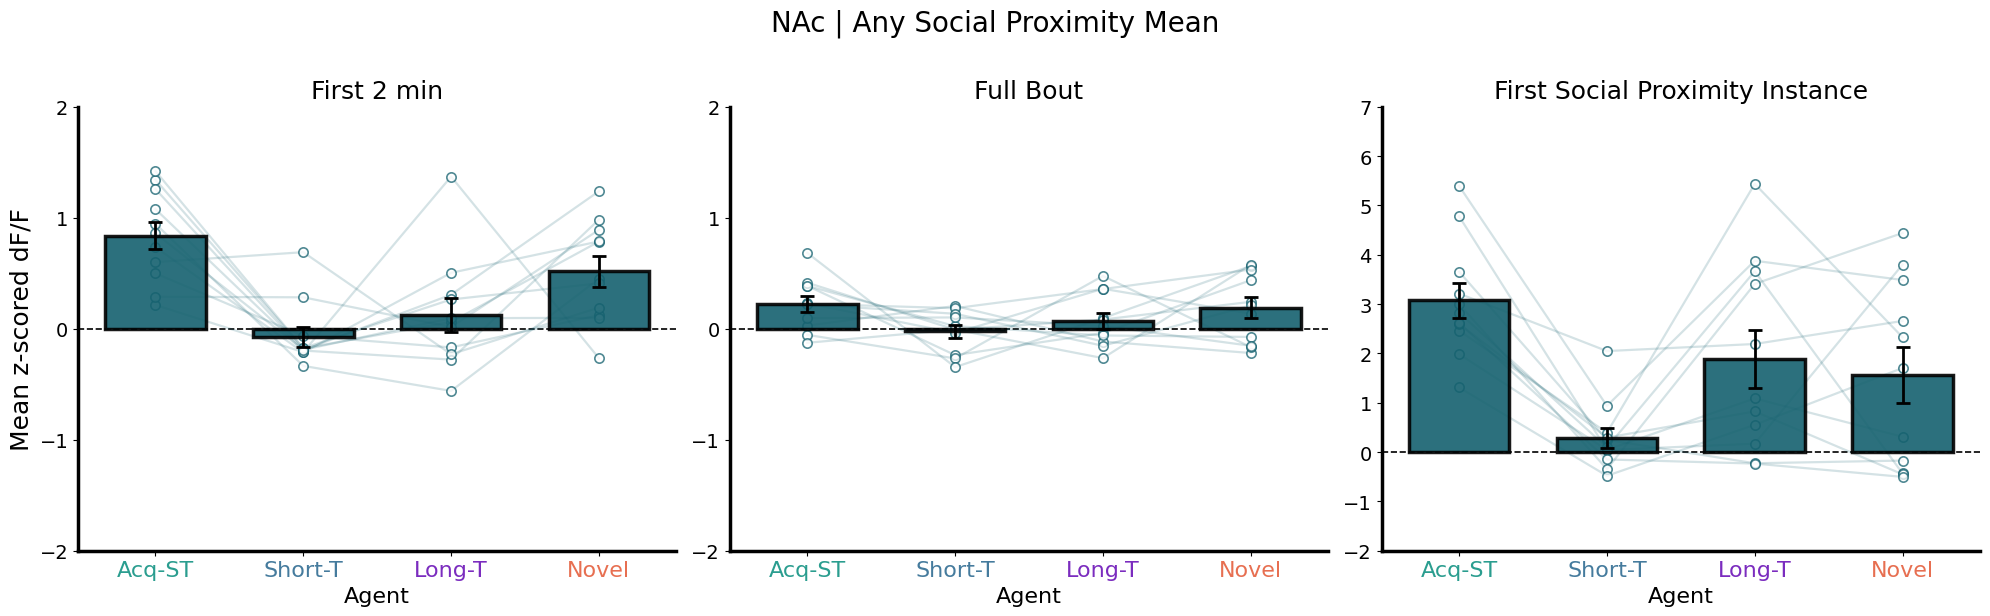

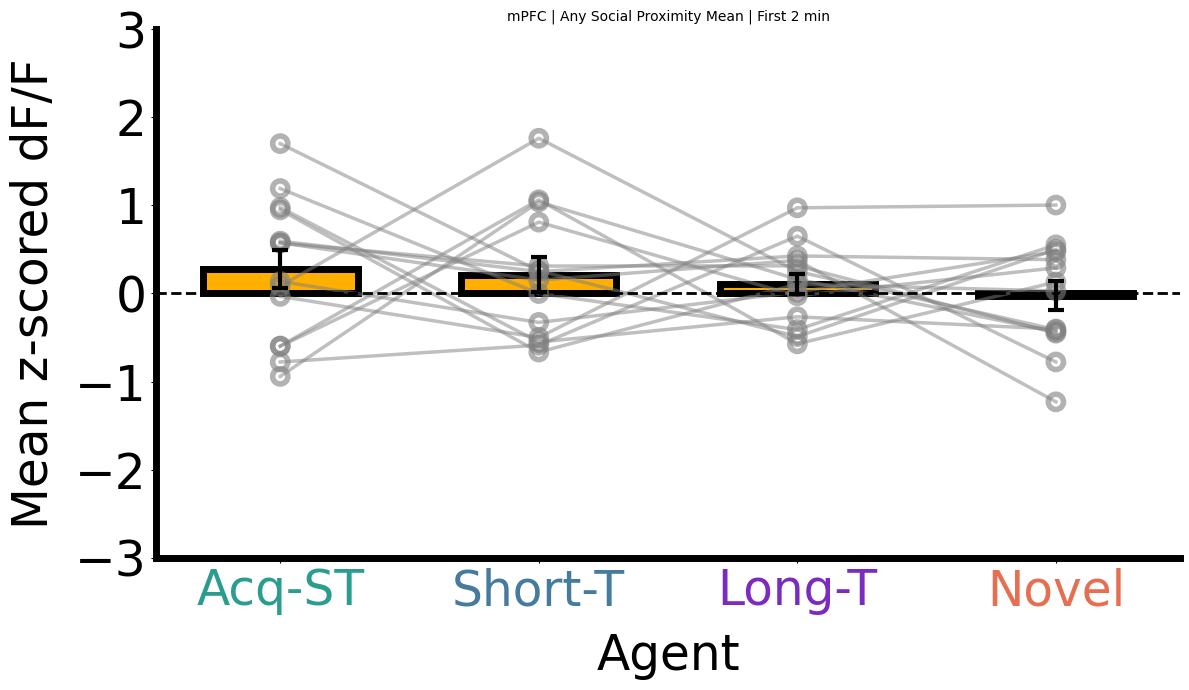


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.1736   0.8649   0.0464
 Short_Term-1 vs Long_Term-1 14  0.5982   0.5600   0.1599
     Short_Term-1 vs Novel-1 14  1.2293   0.2408   0.3285
 Short_Term-2 vs Long_Term-1 14  0.4258   0.6772   0.1138
     Short_Term-2 vs Novel-1 14  0.8787   0.3955   0.2348
      Long_Term-1 vs Novel-1 14  0.6132   0.5503   0.1639


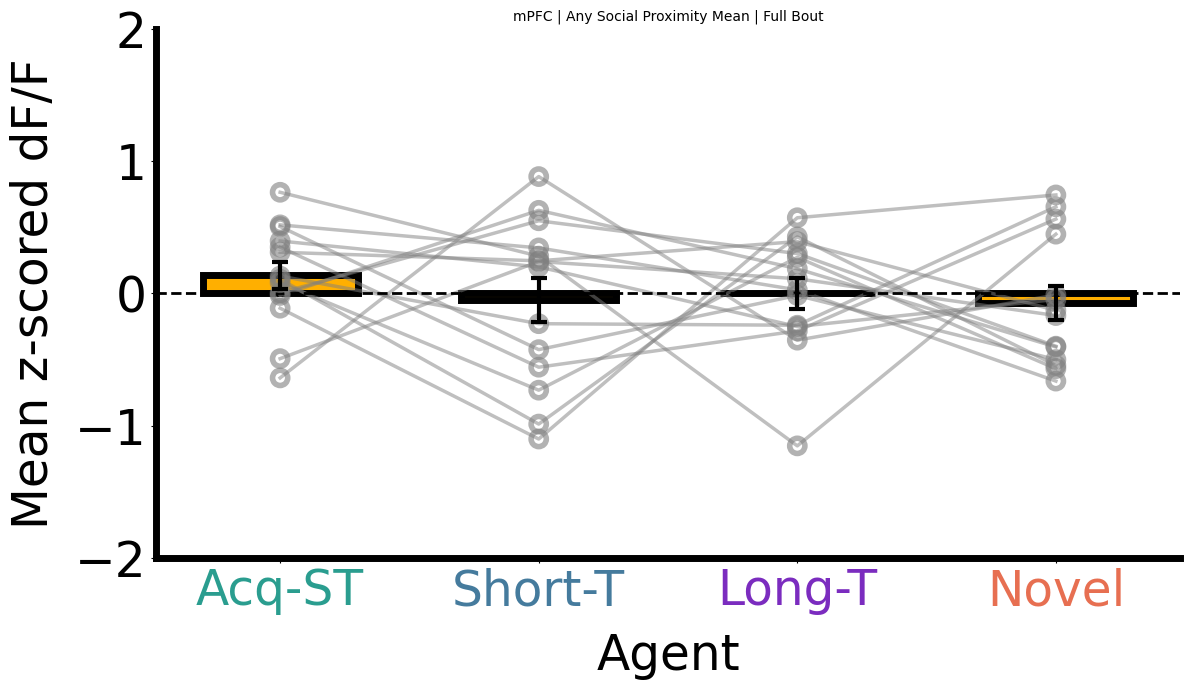


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.8715   0.3993   0.2329
 Short_Term-1 vs Long_Term-1 14  0.7498   0.4667   0.2004
     Short_Term-1 vs Novel-1 14  1.2655   0.2279   0.3382
 Short_Term-2 vs Long_Term-1 14 -0.1959   0.8477  -0.0524
     Short_Term-2 vs Novel-1 14  0.1126   0.9121   0.0301
      Long_Term-1 vs Novel-1 14  0.3519   0.7306   0.0940


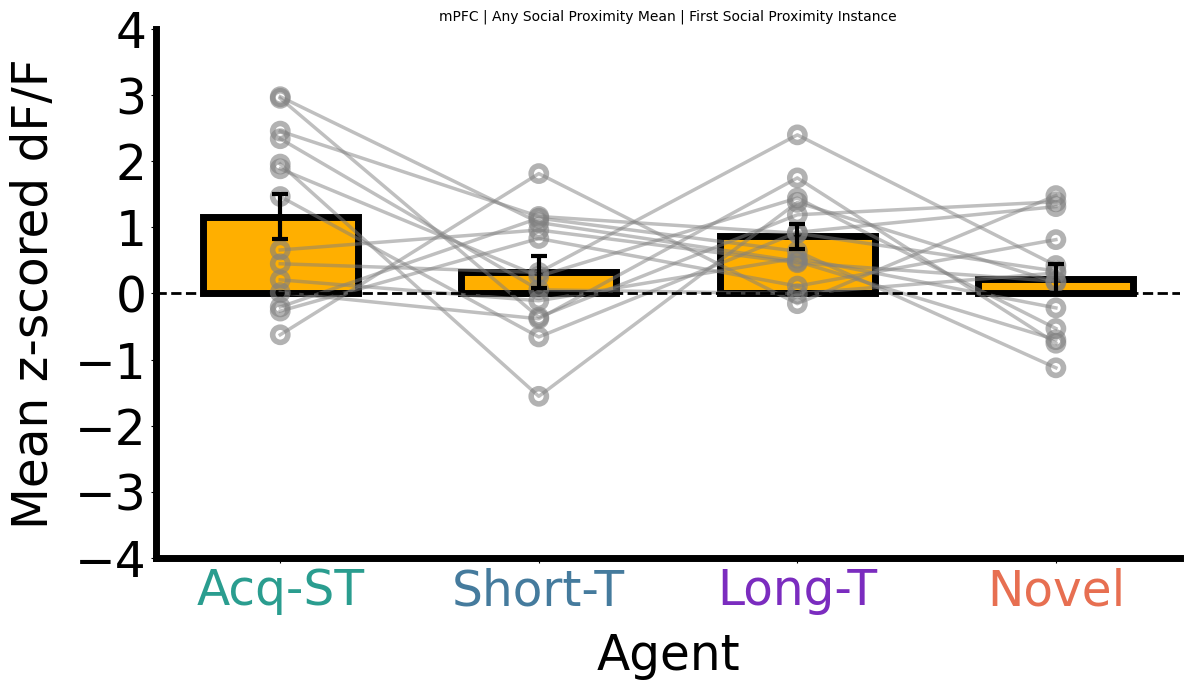


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  1.7741   0.0995   0.4741
 Short_Term-1 vs Long_Term-1 14  0.8112   0.4319   0.2168
     Short_Term-1 vs Novel-1 14  2.3696   0.0340   0.6333
 Short_Term-2 vs Long_Term-1 14 -1.4367   0.1744  -0.3840
     Short_Term-2 vs Novel-1 14  0.3112   0.7606   0.0832
      Long_Term-1 vs Novel-1 14  2.0004   0.0668   0.5346


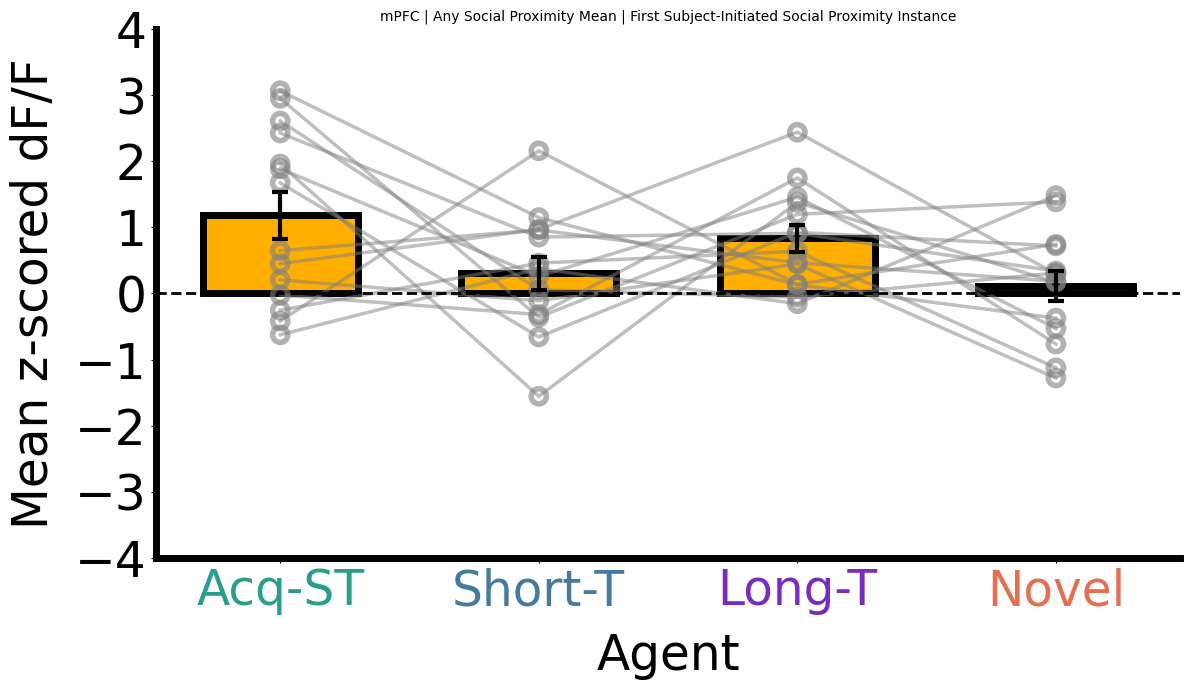


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  1.8334   0.0897   0.4900
 Short_Term-1 vs Long_Term-1 14  0.8753   0.3973   0.2339
     Short_Term-1 vs Novel-1 14  2.7637   0.0161   0.7386
 Short_Term-2 vs Long_Term-1 14 -1.4777   0.1633  -0.3949
     Short_Term-2 vs Novel-1 14  0.5918   0.5641   0.1582
      Long_Term-1 vs Novel-1 14  2.2328   0.0438   0.5967


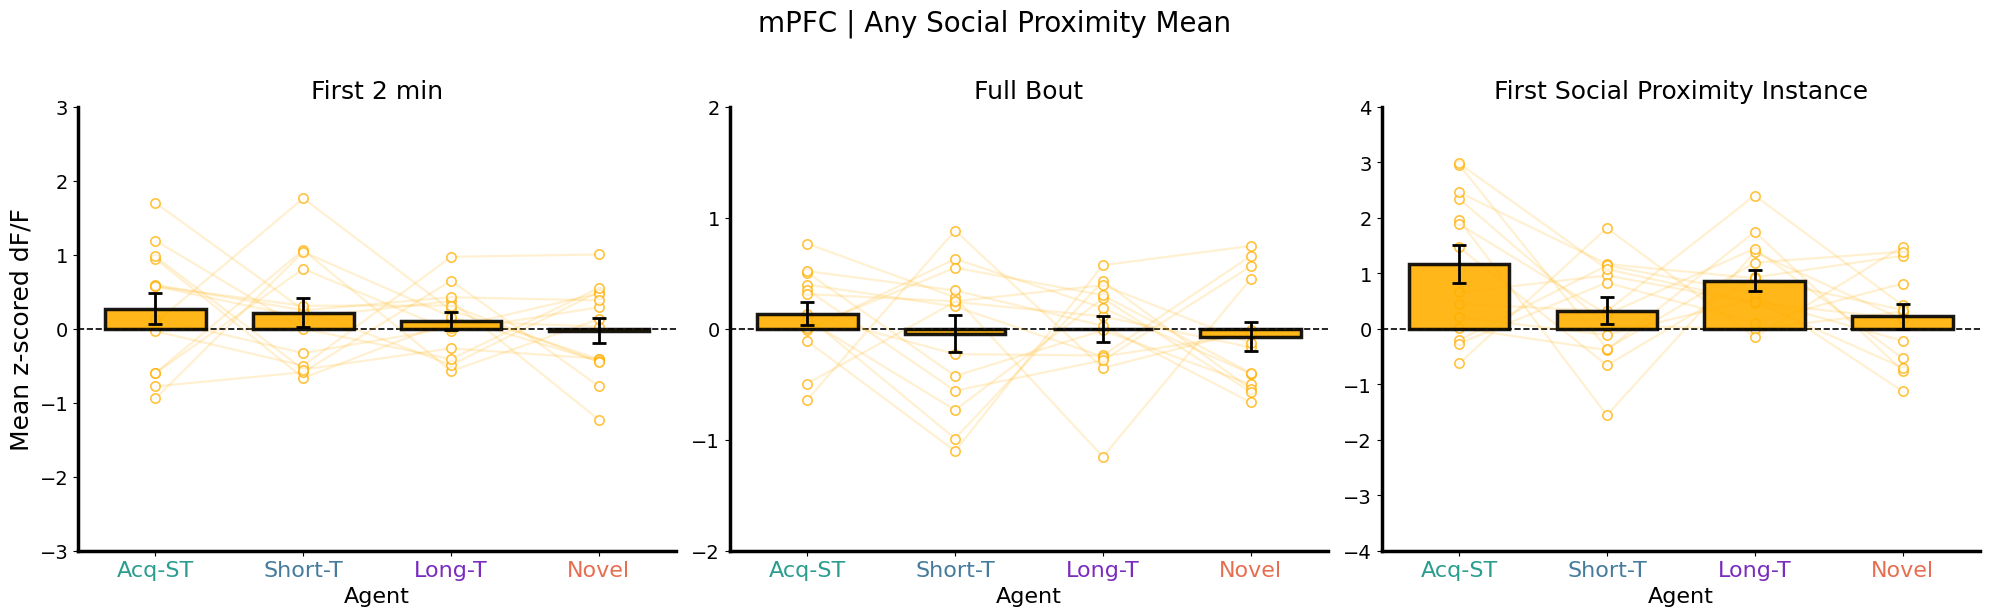

In [7]:
# 1. Any social proximity: each analysis individually, then all three together
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    for analysis_name in ANALYSIS_ORDER:
        plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='social_any')
    plot_all_three_analyses(metadata_df, region_name, behavior_name='social_any')


In [8]:
MANUAL_YLIMS = {
    # ('mPFC', 'first_2min', 'subject_in_agent_with_both'): (-2, 2.0),
    # ('mPFC', 'full_bout', 'subject_in_agent_with_both'): (-2, 2),
    ('NAc', 'first_social_instance', 'subject_in_agent_with_both'): (-2, 7),
    # ('mPFC', 'full_bout', 'subject_in_agent_only'): (-1, 1),
}

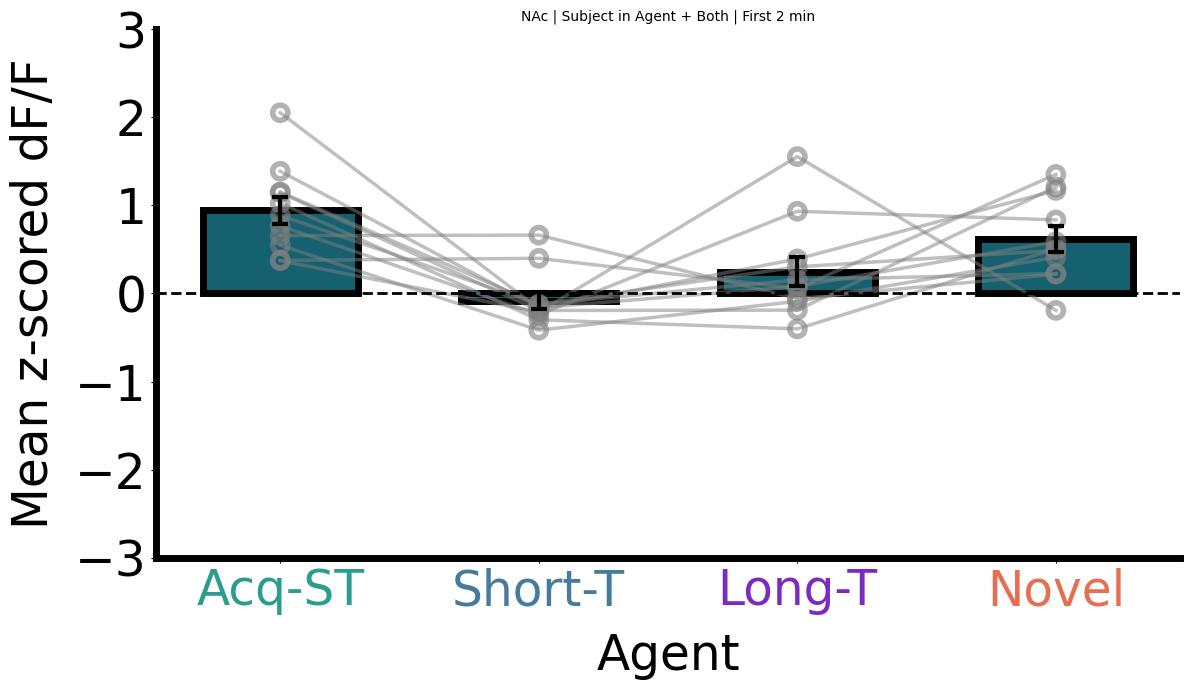


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  5.1558   0.0004   1.5545
 Short_Term-1 vs Long_Term-1 11  2.8135   0.0184   0.8483
     Short_Term-1 vs Novel-1 11  1.9885   0.0748   0.5995
 Short_Term-2 vs Long_Term-1 11 -1.5907   0.1428  -0.4796
     Short_Term-2 vs Novel-1 11 -4.2048   0.0018  -1.2678
      Long_Term-1 vs Novel-1 11 -1.4463   0.1787  -0.4361


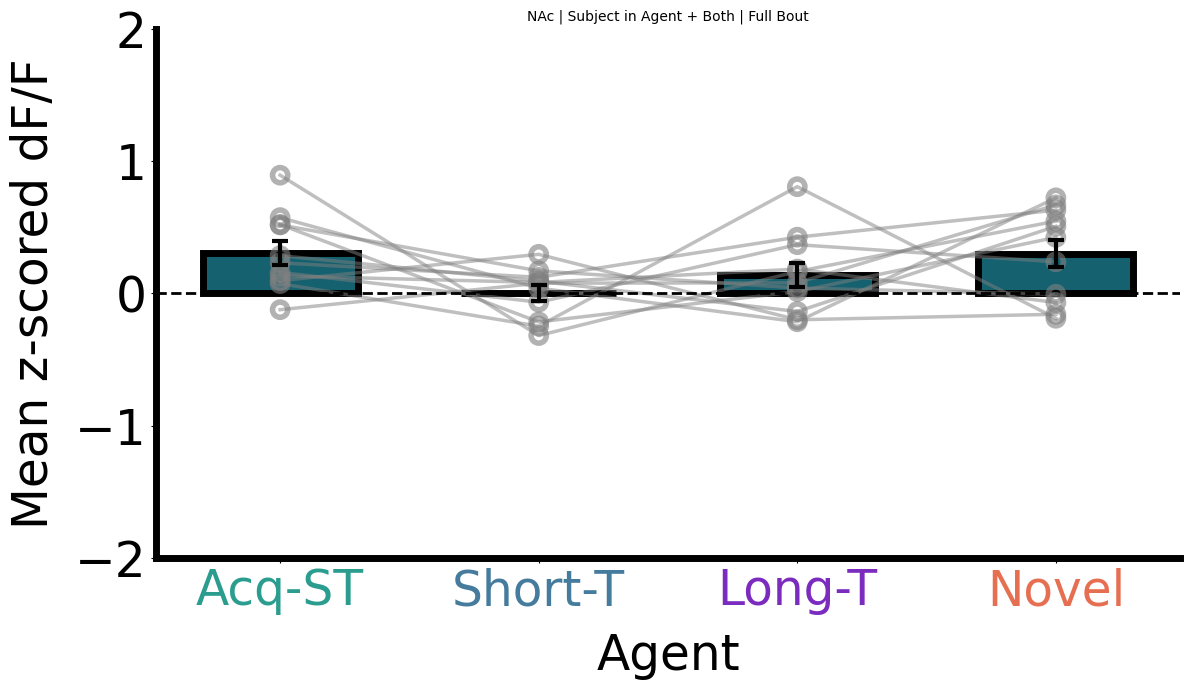


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  2.4384   0.0349   0.7352
 Short_Term-1 vs Long_Term-1 11  1.1590   0.2734   0.3495
     Short_Term-1 vs Novel-1 11  0.0360   0.9720   0.0109
 Short_Term-2 vs Long_Term-1 11 -1.0489   0.3189  -0.3163
     Short_Term-2 vs Novel-1 11 -2.3478   0.0408  -0.7079
      Long_Term-1 vs Novel-1 11 -1.0189   0.3323  -0.3072


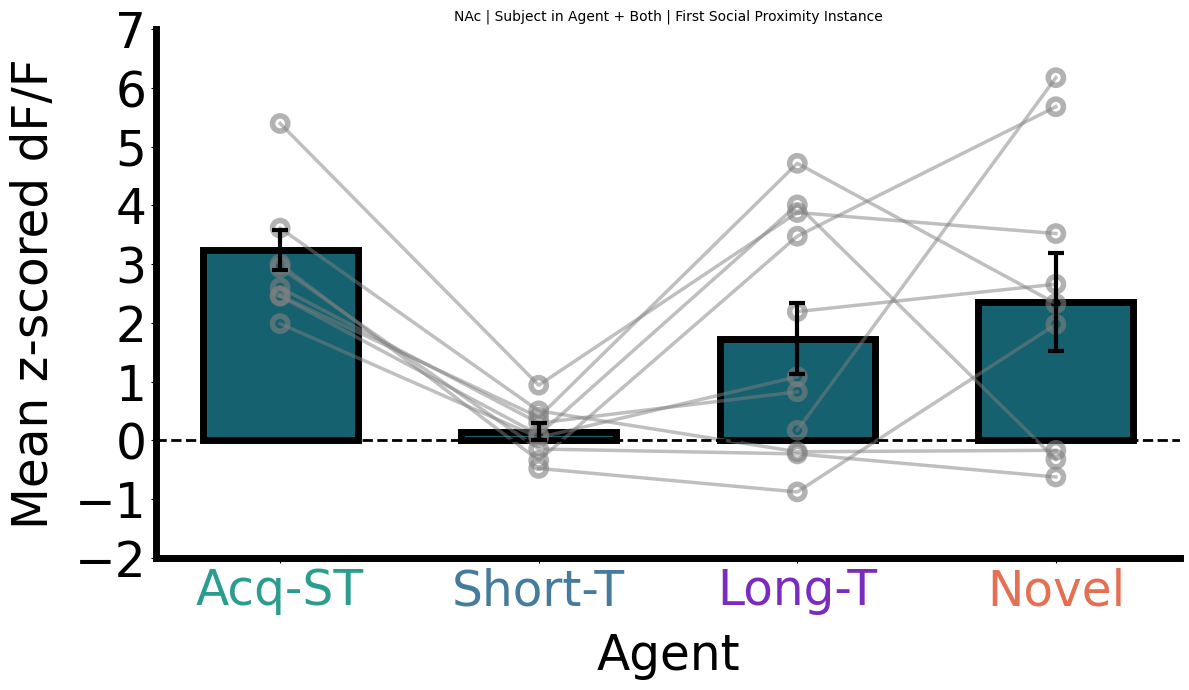


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  8  9.5563   0.0000   3.3787
 Short_Term-1 vs Long_Term-1 10  1.7673   0.1110   0.5589
     Short_Term-1 vs Novel-1  8  1.2997   0.2349   0.4595
 Short_Term-2 vs Long_Term-1  9 -2.5267   0.0354  -0.8422
     Short_Term-2 vs Novel-1  7 -1.7904   0.1236  -0.6767
      Long_Term-1 vs Novel-1  9 -0.4529   0.6627  -0.1510


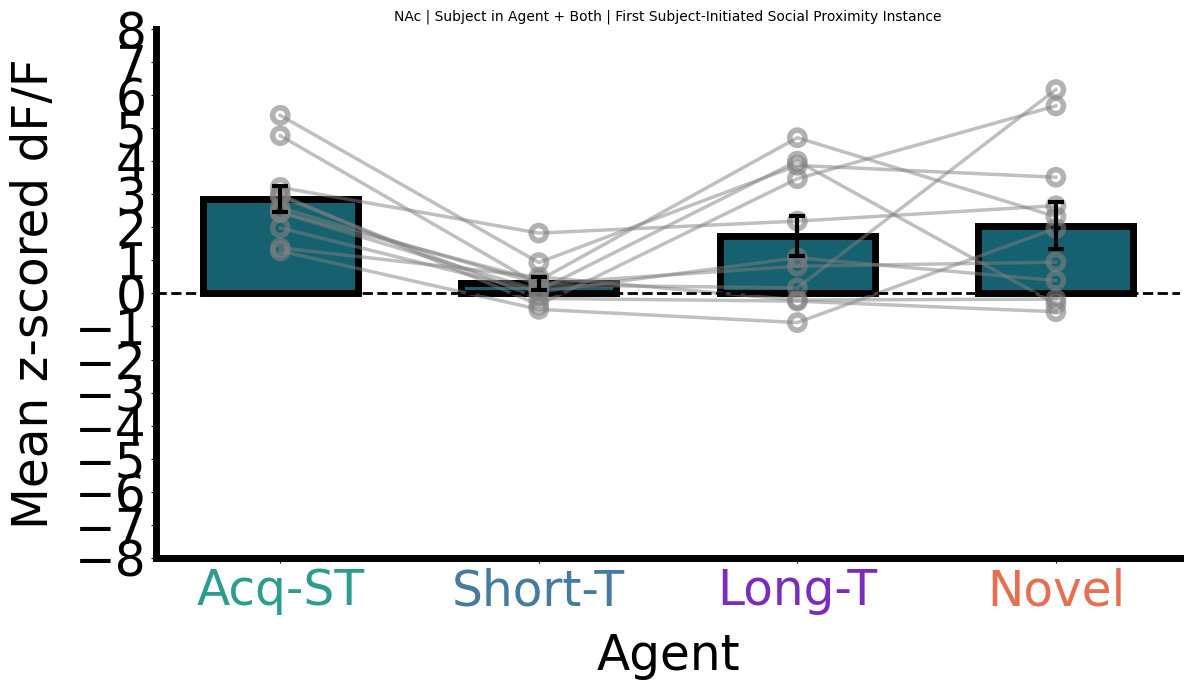


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  7.1912   0.0000   2.1682
 Short_Term-1 vs Long_Term-1 11  1.8917   0.0878   0.5704
     Short_Term-1 vs Novel-1 11  1.4523   0.1771   0.4379
 Short_Term-2 vs Long_Term-1 11 -2.4514   0.0342  -0.7391
     Short_Term-2 vs Novel-1 11 -2.4513   0.0342  -0.7391
      Long_Term-1 vs Novel-1 11 -0.4000   0.6976  -0.1206


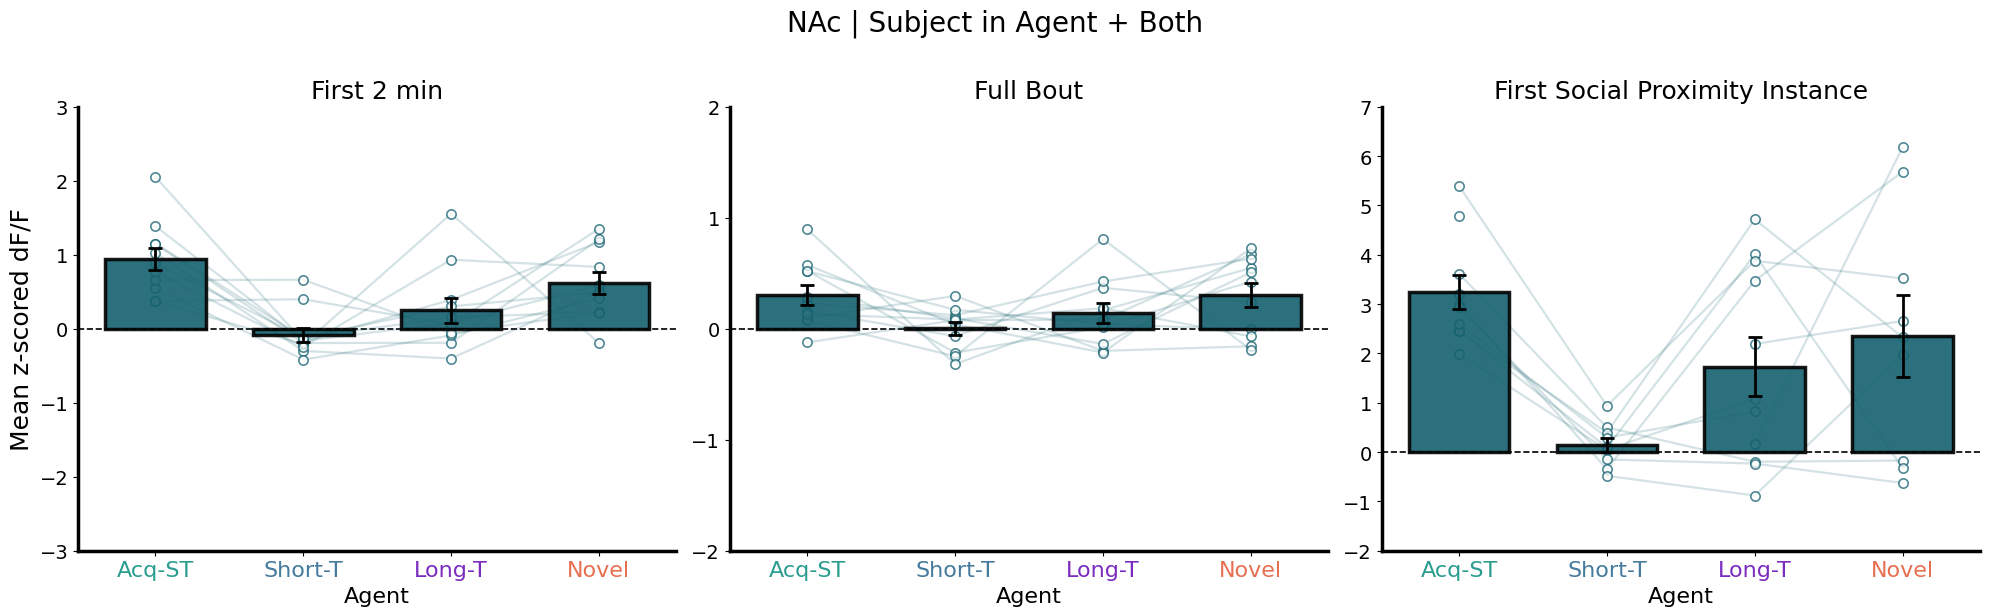

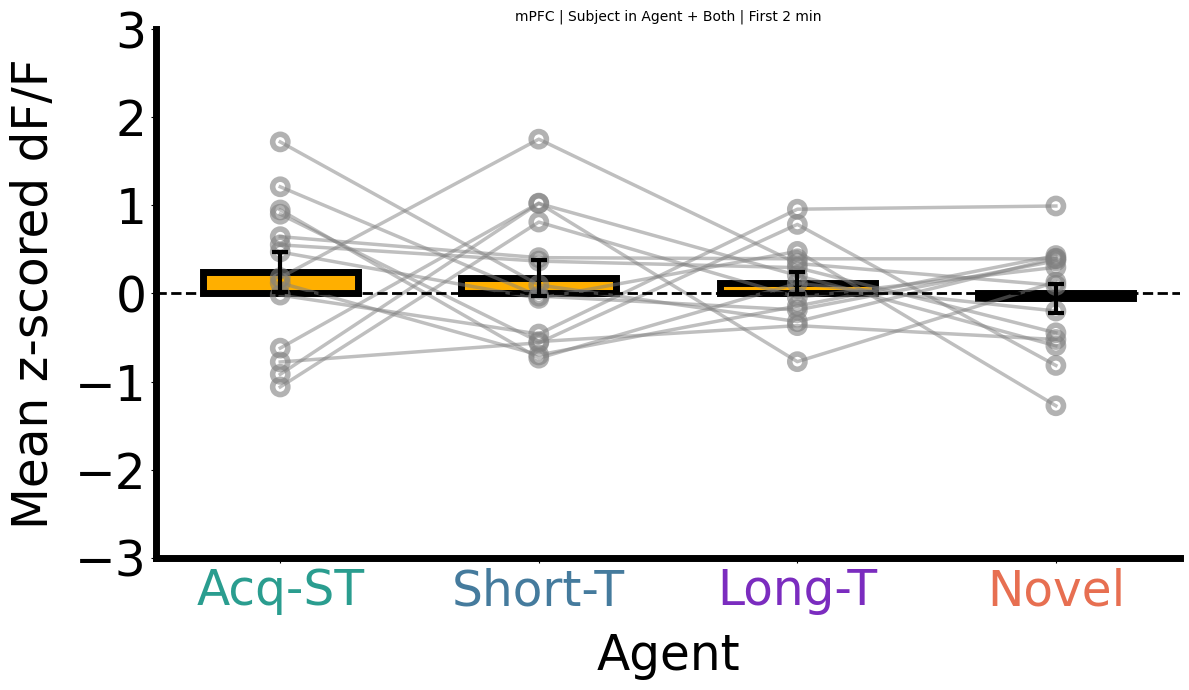


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.1931   0.8499   0.0516
 Short_Term-1 vs Long_Term-1 14  0.4144   0.6853   0.1108
     Short_Term-1 vs Novel-1 14  1.1249   0.2810   0.3006
 Short_Term-2 vs Long_Term-1 14  0.1845   0.8565   0.0493
     Short_Term-2 vs Novel-1 14  0.8798   0.3949   0.2351
      Long_Term-1 vs Novel-1 14  0.8131   0.4308   0.2173


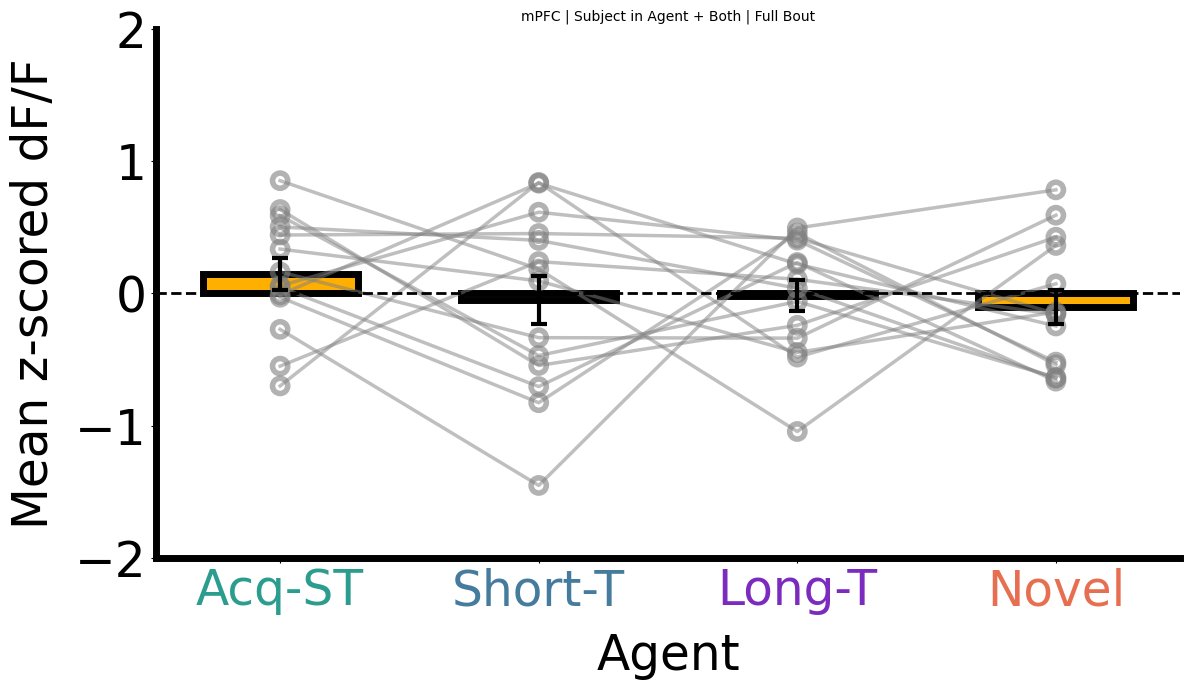


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.8618   0.4044   0.2303
 Short_Term-1 vs Long_Term-1 14  0.8383   0.4170   0.2240
     Short_Term-1 vs Novel-1 14  1.3878   0.1885   0.3709
 Short_Term-2 vs Long_Term-1 14 -0.1279   0.9001  -0.0342
     Short_Term-2 vs Novel-1 14  0.2230   0.8270   0.0596
      Long_Term-1 vs Novel-1 14  0.4238   0.6786   0.1133


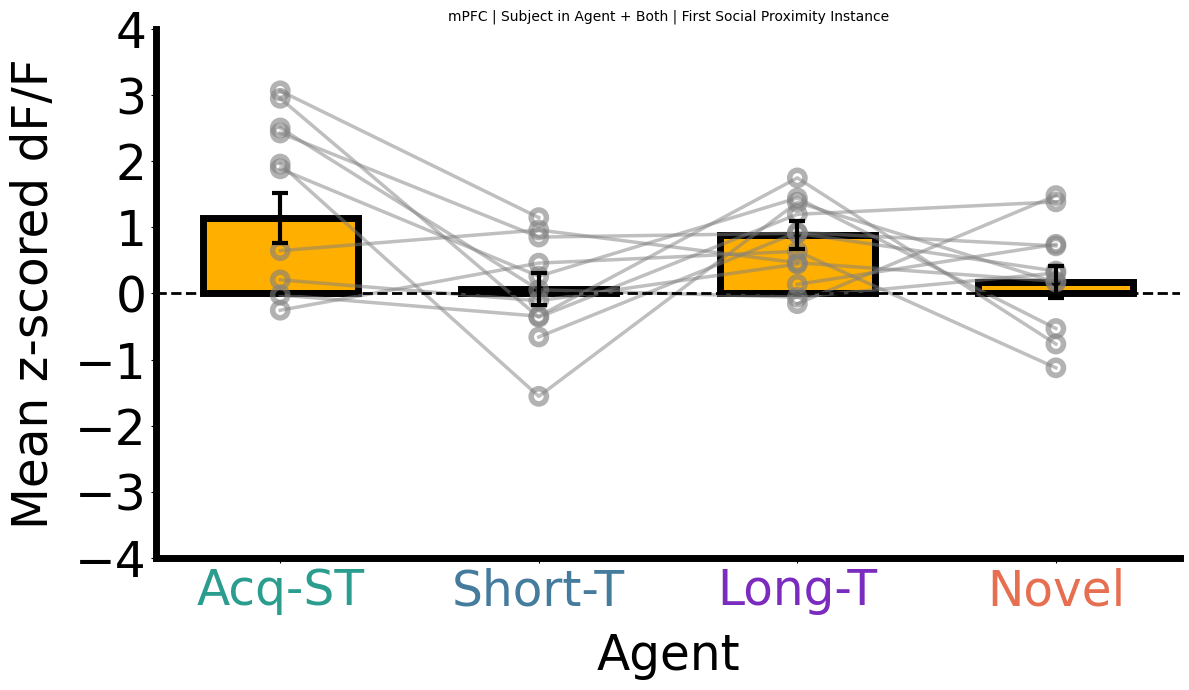


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 10  3.0235   0.0144   0.9561
 Short_Term-1 vs Long_Term-1 12  0.2336   0.8196   0.0674
     Short_Term-1 vs Novel-1 11  2.2858   0.0453   0.6892
 Short_Term-2 vs Long_Term-1 10 -2.7498   0.0225  -0.8696
     Short_Term-2 vs Novel-1 10  0.2180   0.8323   0.0689
      Long_Term-1 vs Novel-1 11  1.3869   0.1956   0.4182


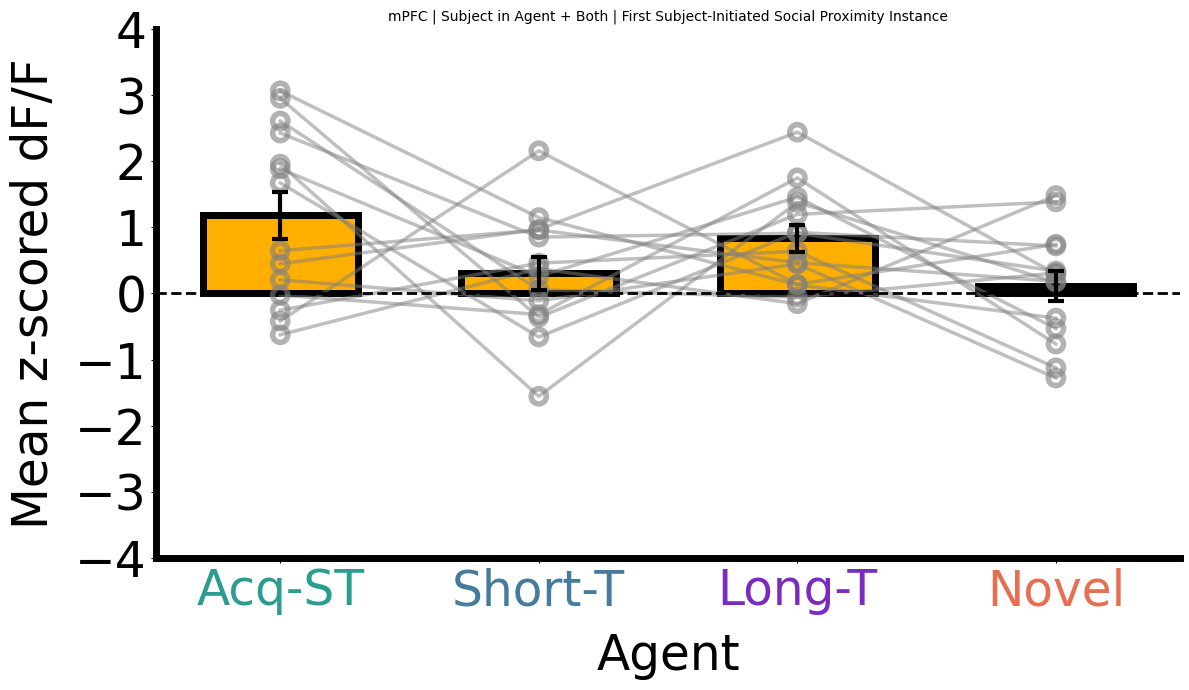


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  1.8334   0.0897   0.4900
 Short_Term-1 vs Long_Term-1 14  0.8753   0.3973   0.2339
     Short_Term-1 vs Novel-1 14  2.7637   0.0161   0.7386
 Short_Term-2 vs Long_Term-1 14 -1.4777   0.1633  -0.3949
     Short_Term-2 vs Novel-1 14  0.5918   0.5641   0.1582
      Long_Term-1 vs Novel-1 14  2.2328   0.0438   0.5967


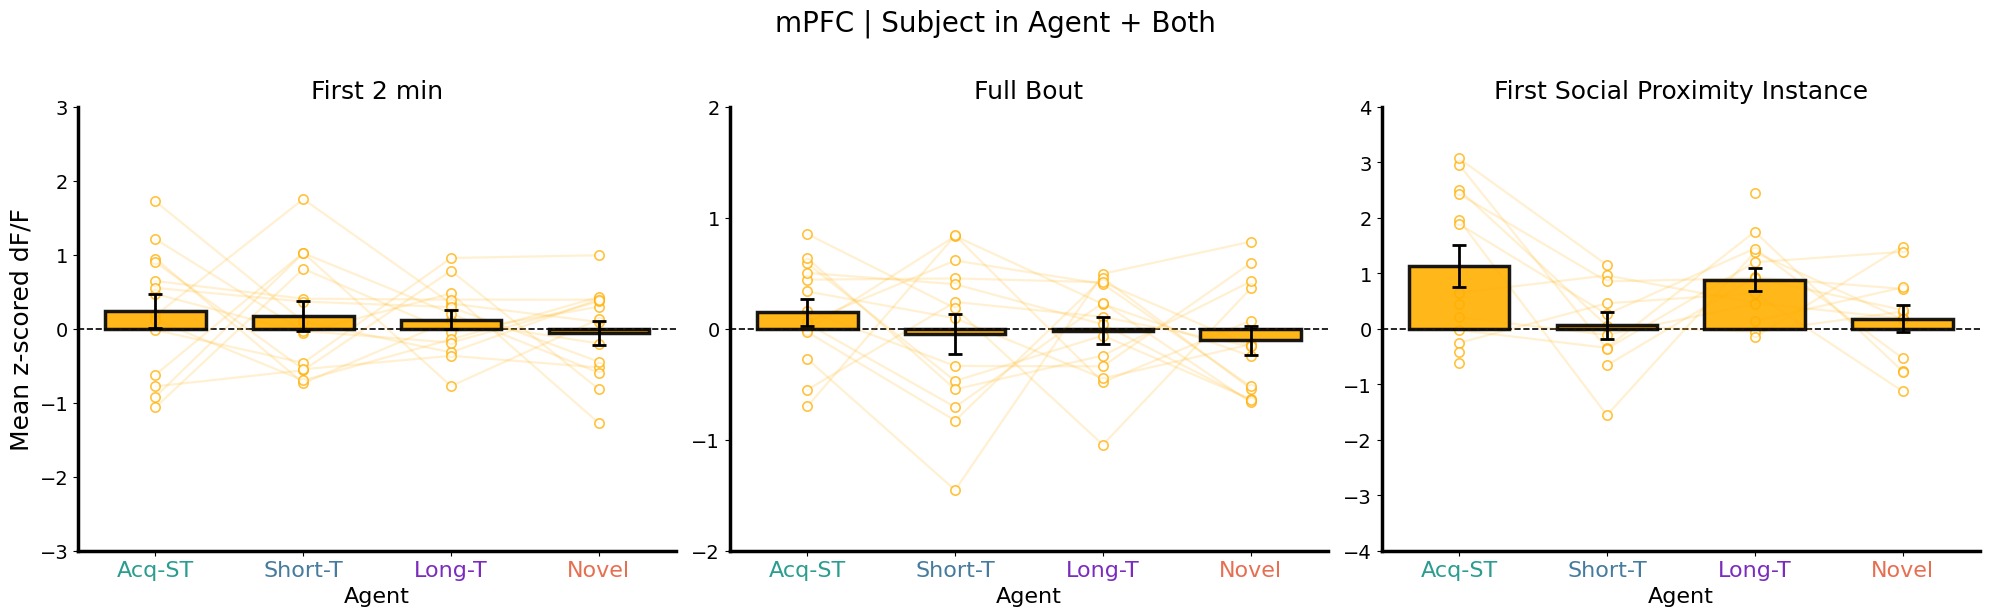

In [9]:
# 1. Any social proximity: each analysis individually, then all three together
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    for analysis_name in ANALYSIS_ORDER:
        plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='subject_in_agent_with_both')
    plot_all_three_analyses(metadata_df, region_name, behavior_name='subject_in_agent_with_both')


In [10]:
MANUAL_YLIMS = {
    # ('mPFC', 'first_2min', 'subject_in_agent_with_both'): (-2, 2.0),
    # ('mPFC', 'full_bout', 'subject_in_agent_with_both'): (-2, 2),
    ('NAc', 'first_social_instance', 'agent_in_subject_only'): (-2, 7),
    # ('mPFC', 'full_bout', 'subject_in_agent_only'): (-1, 1),
}

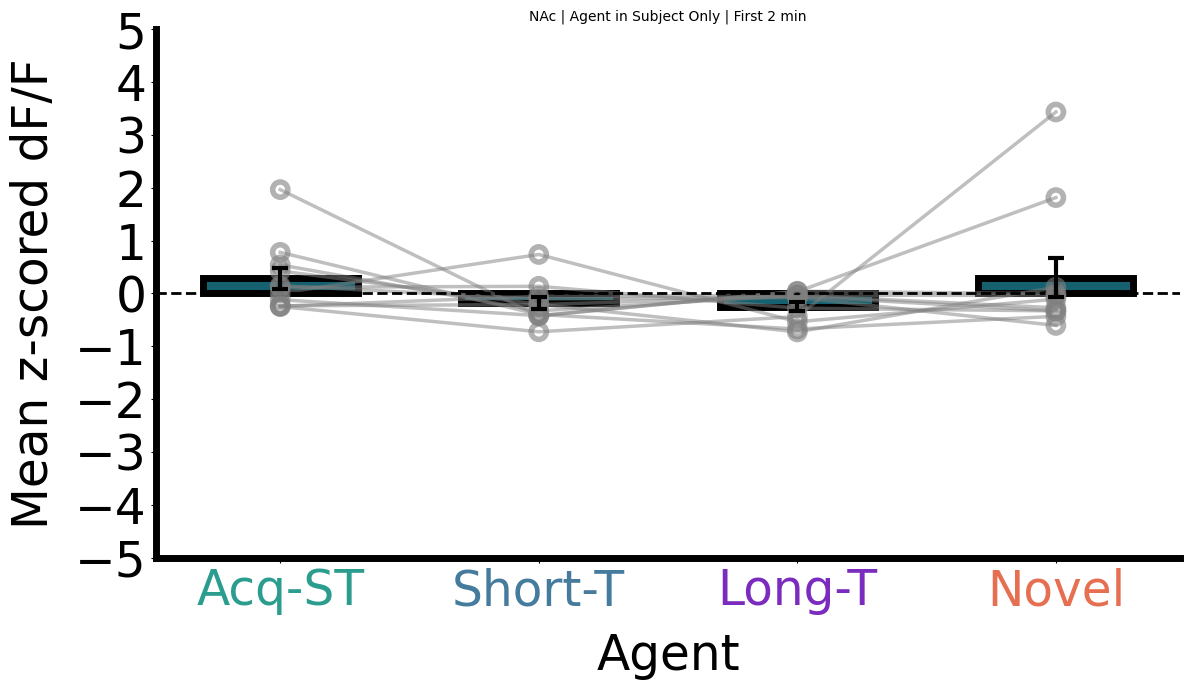


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  1.8744   0.0904   0.5651
 Short_Term-1 vs Long_Term-1 11  2.5432   0.0292   0.7668
     Short_Term-1 vs Novel-1 11 -0.0220   0.9829  -0.0066
 Short_Term-2 vs Long_Term-1 11  0.4546   0.6591   0.1371
     Short_Term-2 vs Novel-1 11 -1.0844   0.3037  -0.3270
      Long_Term-1 vs Novel-1 11 -1.4269   0.1841  -0.4302


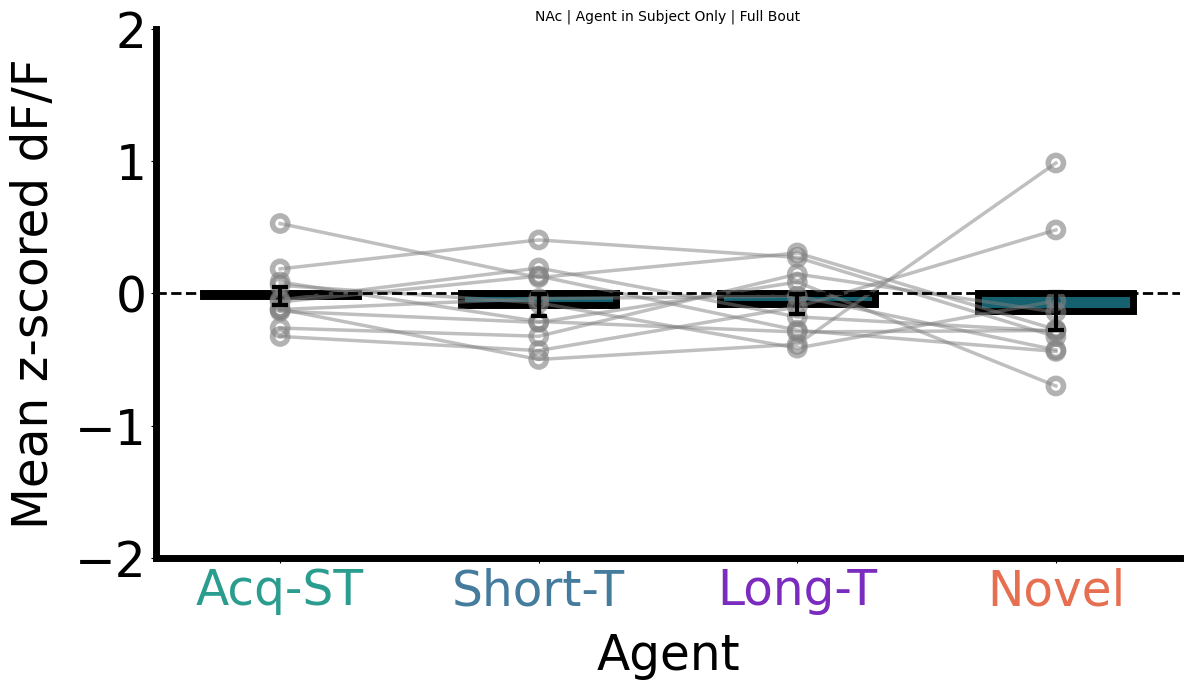


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  0.9499   0.3645   0.2864
 Short_Term-1 vs Long_Term-1 11  0.6872   0.5076   0.2072
     Short_Term-1 vs Novel-1 11  0.6445   0.5337   0.1943
 Short_Term-2 vs Long_Term-1 11 -0.0919   0.9286  -0.0277
     Short_Term-2 vs Novel-1 11  0.2261   0.8257   0.0682
      Long_Term-1 vs Novel-1 11  0.2917   0.7765   0.0880


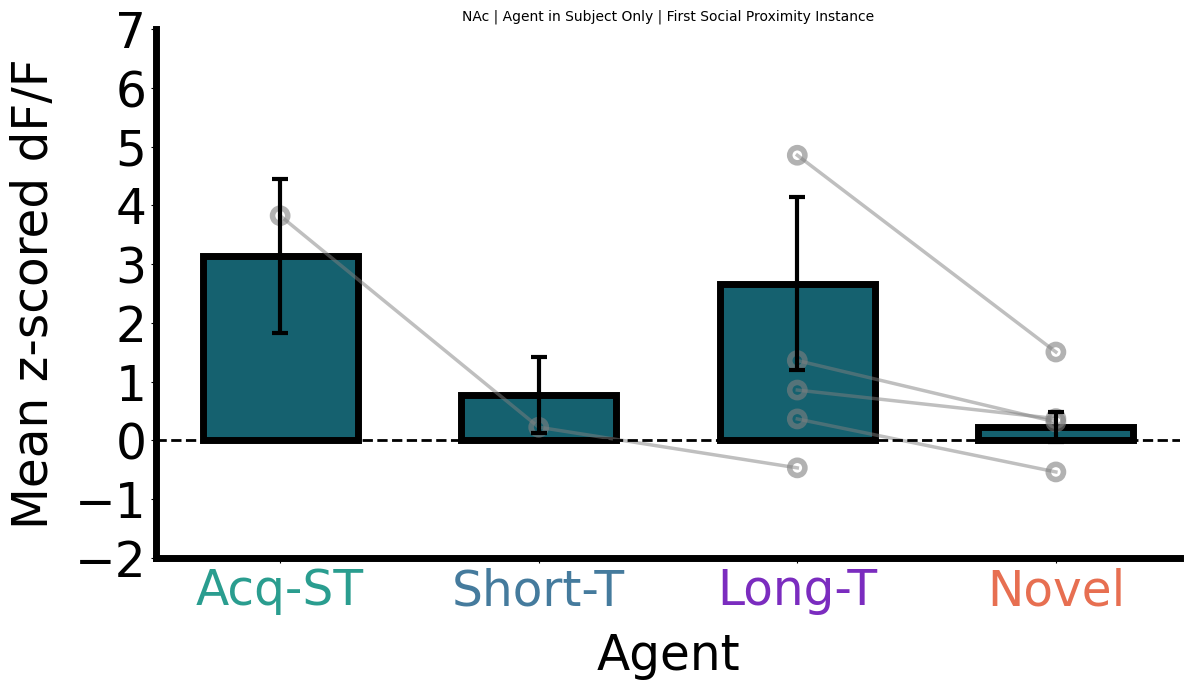


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  1     NaN      NaN      NaN
 Short_Term-1 vs Long_Term-1  3  0.7774   0.5183   0.4488
     Short_Term-1 vs Novel-1  3  1.2198   0.3469   0.7043
 Short_Term-2 vs Long_Term-1  1     NaN      NaN      NaN
     Short_Term-2 vs Novel-1  1     NaN      NaN      NaN
      Long_Term-1 vs Novel-1  4  2.2399   0.1110   1.1200


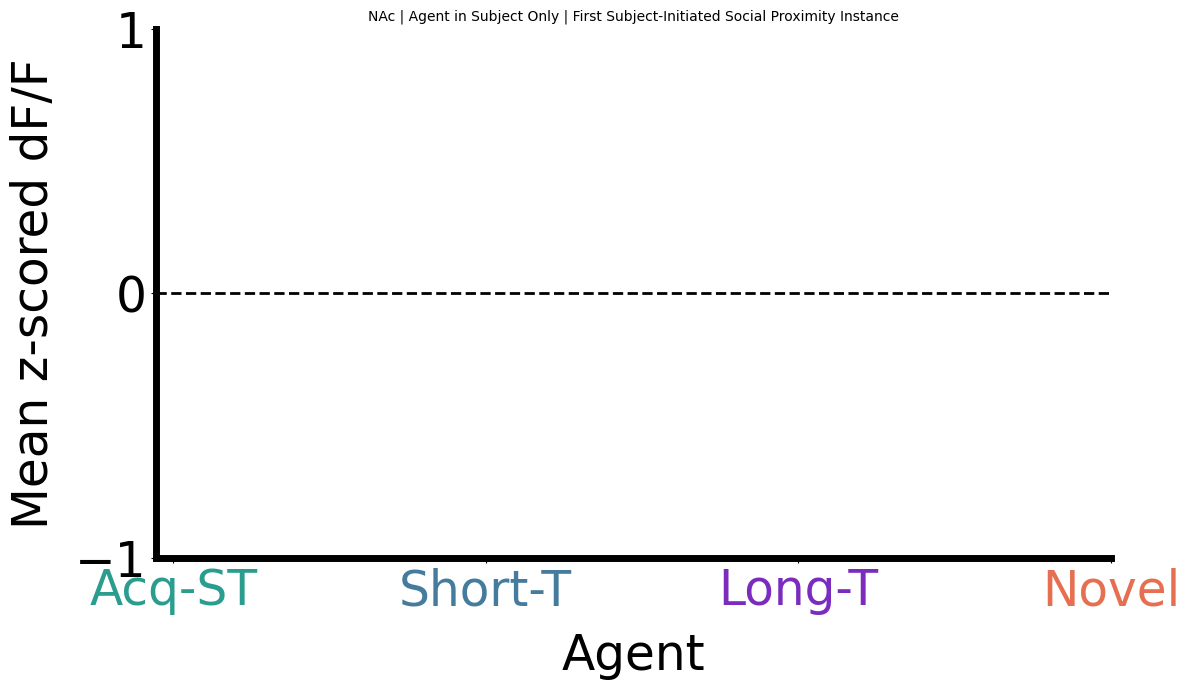


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  0     NaN      NaN      NaN
 Short_Term-1 vs Long_Term-1  0     NaN      NaN      NaN
     Short_Term-1 vs Novel-1  0     NaN      NaN      NaN
 Short_Term-2 vs Long_Term-1  0     NaN      NaN      NaN
     Short_Term-2 vs Novel-1  0     NaN      NaN      NaN
      Long_Term-1 vs Novel-1  0     NaN      NaN      NaN


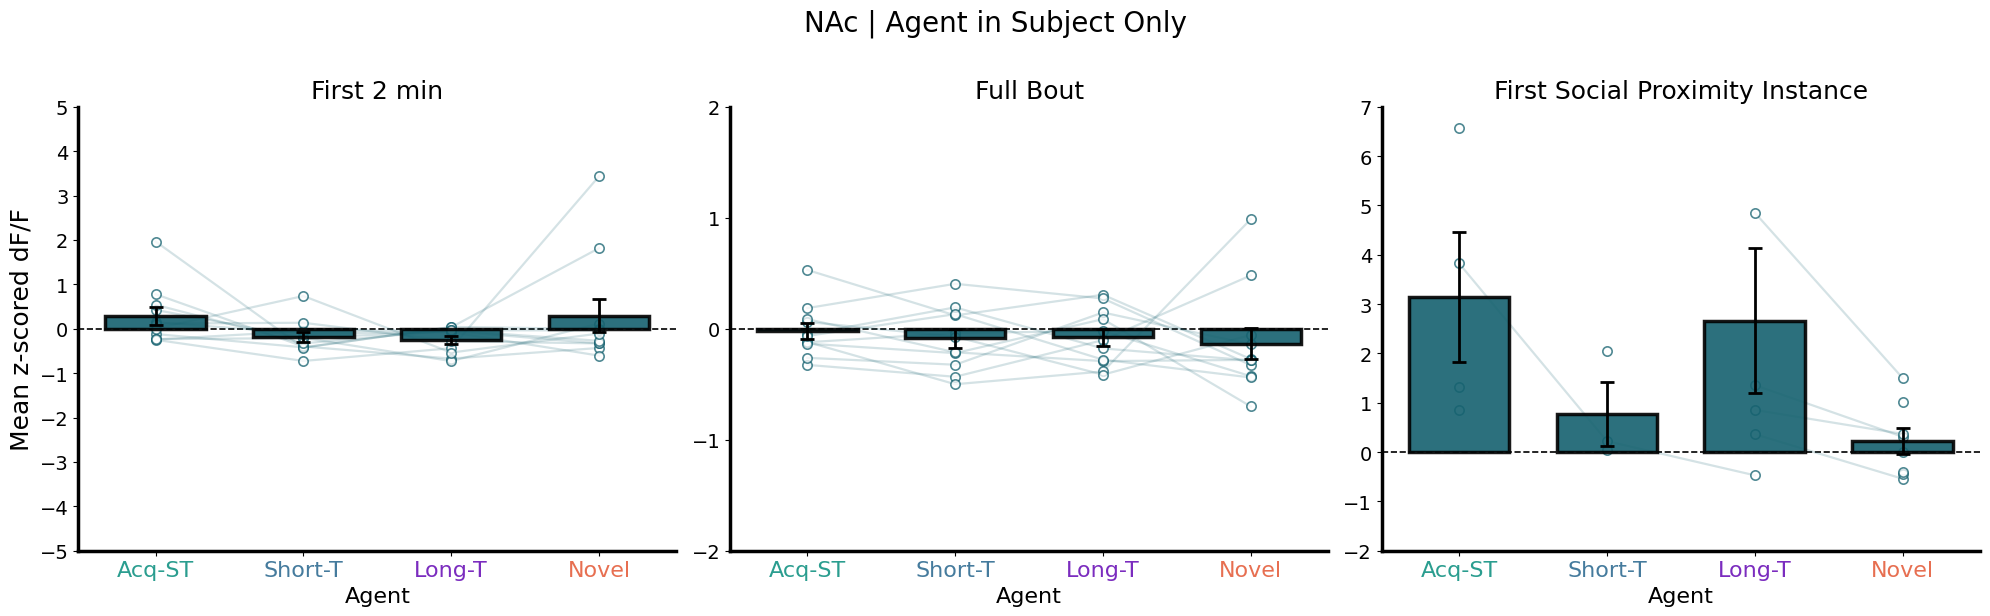

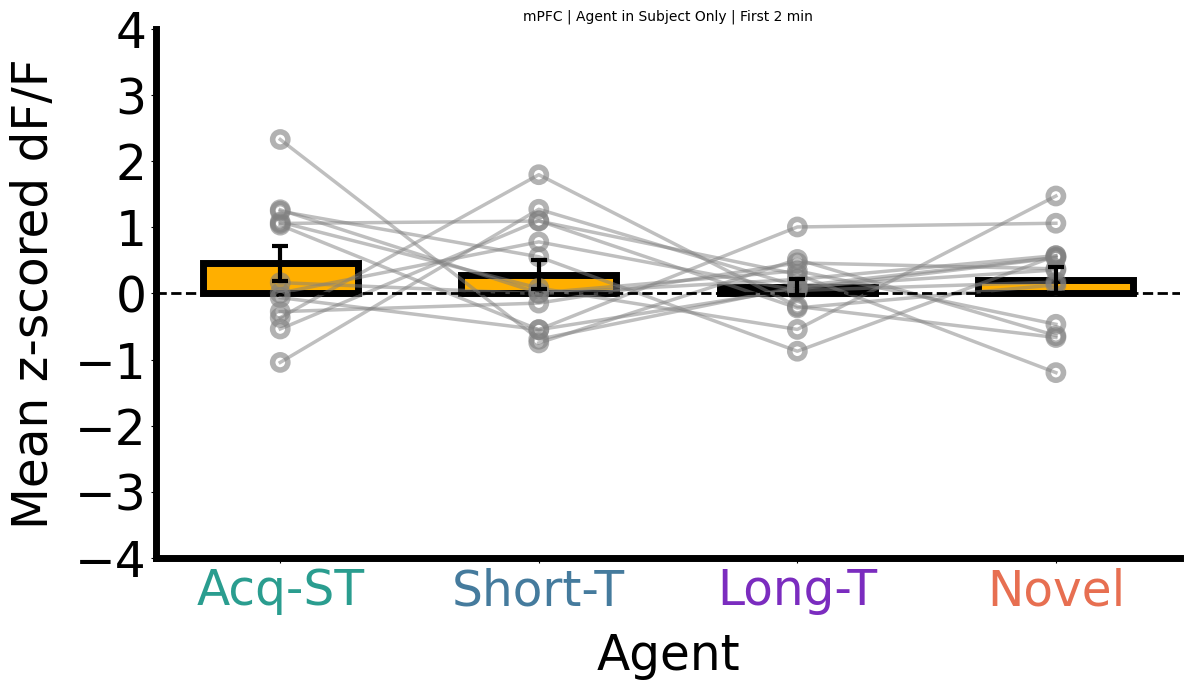


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 13  0.2072   0.8393   0.0575
 Short_Term-1 vs Long_Term-1 13  1.2388   0.2391   0.3436
     Short_Term-1 vs Novel-1 13  0.5623   0.5843   0.1559
 Short_Term-2 vs Long_Term-1 14  0.6539   0.5246   0.1748
     Short_Term-2 vs Novel-1 14  0.2499   0.8065   0.0668
      Long_Term-1 vs Novel-1 14 -0.4353   0.6705  -0.1163


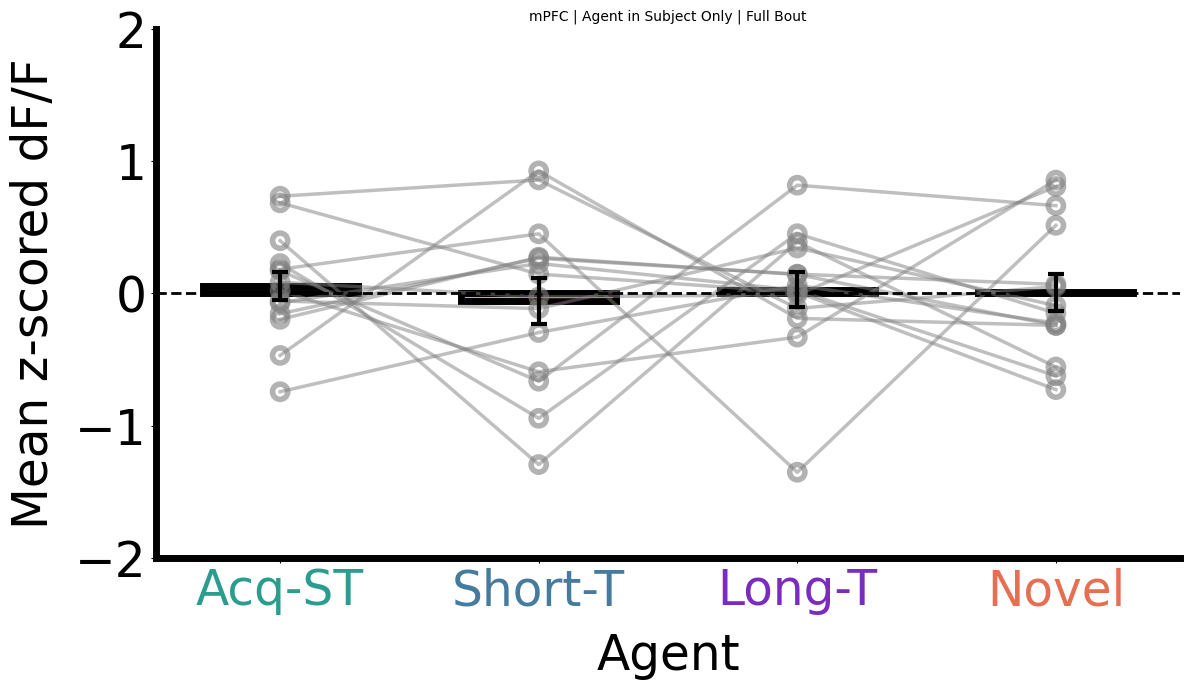


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.5396   0.5986   0.1442
 Short_Term-1 vs Long_Term-1 14  0.1786   0.8610   0.0477
     Short_Term-1 vs Novel-1 14  0.2845   0.7805   0.0760
 Short_Term-2 vs Long_Term-1 14 -0.3164   0.7568  -0.0845
     Short_Term-2 vs Novel-1 14 -0.2789   0.7847  -0.0745
      Long_Term-1 vs Novel-1 14  0.0951   0.9257   0.0254


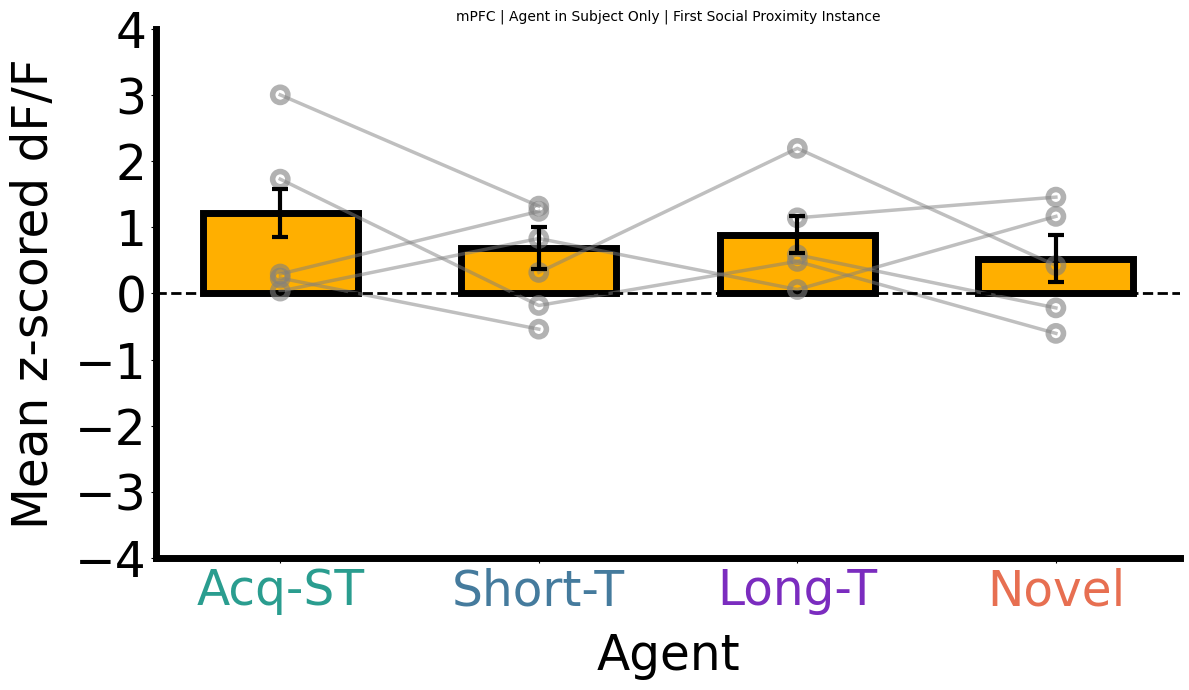


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  5  0.8724   0.4322   0.3901
 Short_Term-1 vs Long_Term-1  3  1.8915   0.1991   1.0920
     Short_Term-1 vs Novel-1  4  0.4857   0.6605   0.2428
 Short_Term-2 vs Long_Term-1  3 -0.7716   0.5211  -0.4455
     Short_Term-2 vs Novel-1  4 -0.3627   0.7409  -0.1814
      Long_Term-1 vs Novel-1  5  0.8735   0.4317   0.3906


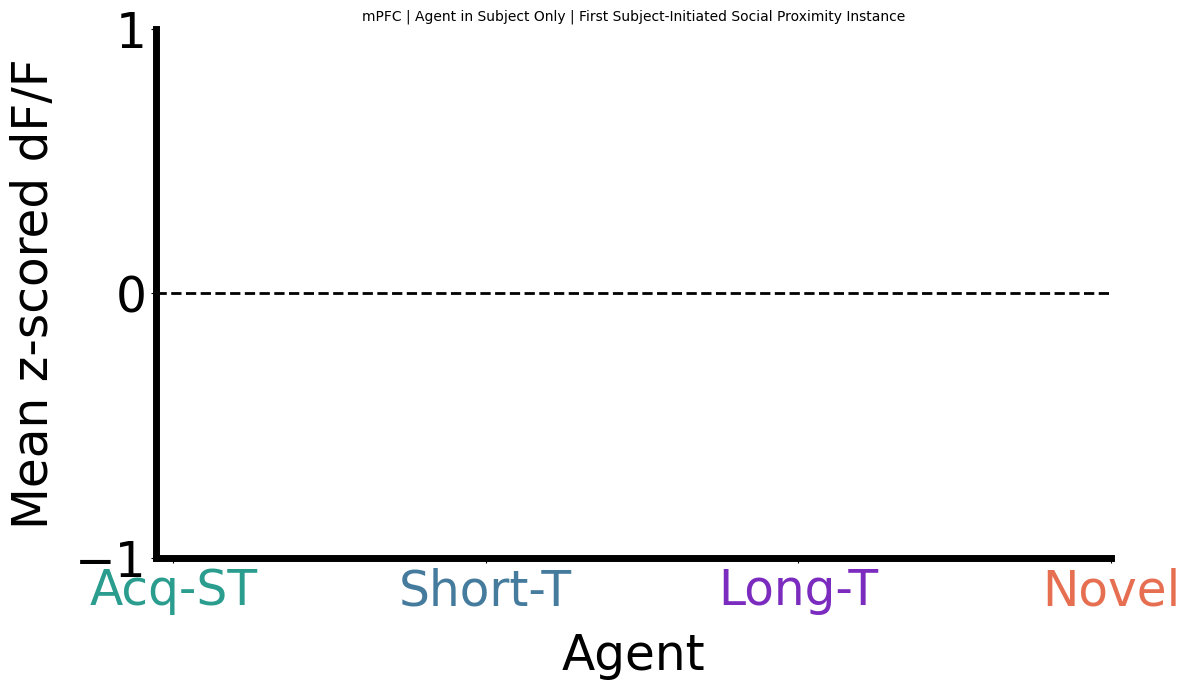


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  0     NaN      NaN      NaN
 Short_Term-1 vs Long_Term-1  0     NaN      NaN      NaN
     Short_Term-1 vs Novel-1  0     NaN      NaN      NaN
 Short_Term-2 vs Long_Term-1  0     NaN      NaN      NaN
     Short_Term-2 vs Novel-1  0     NaN      NaN      NaN
      Long_Term-1 vs Novel-1  0     NaN      NaN      NaN


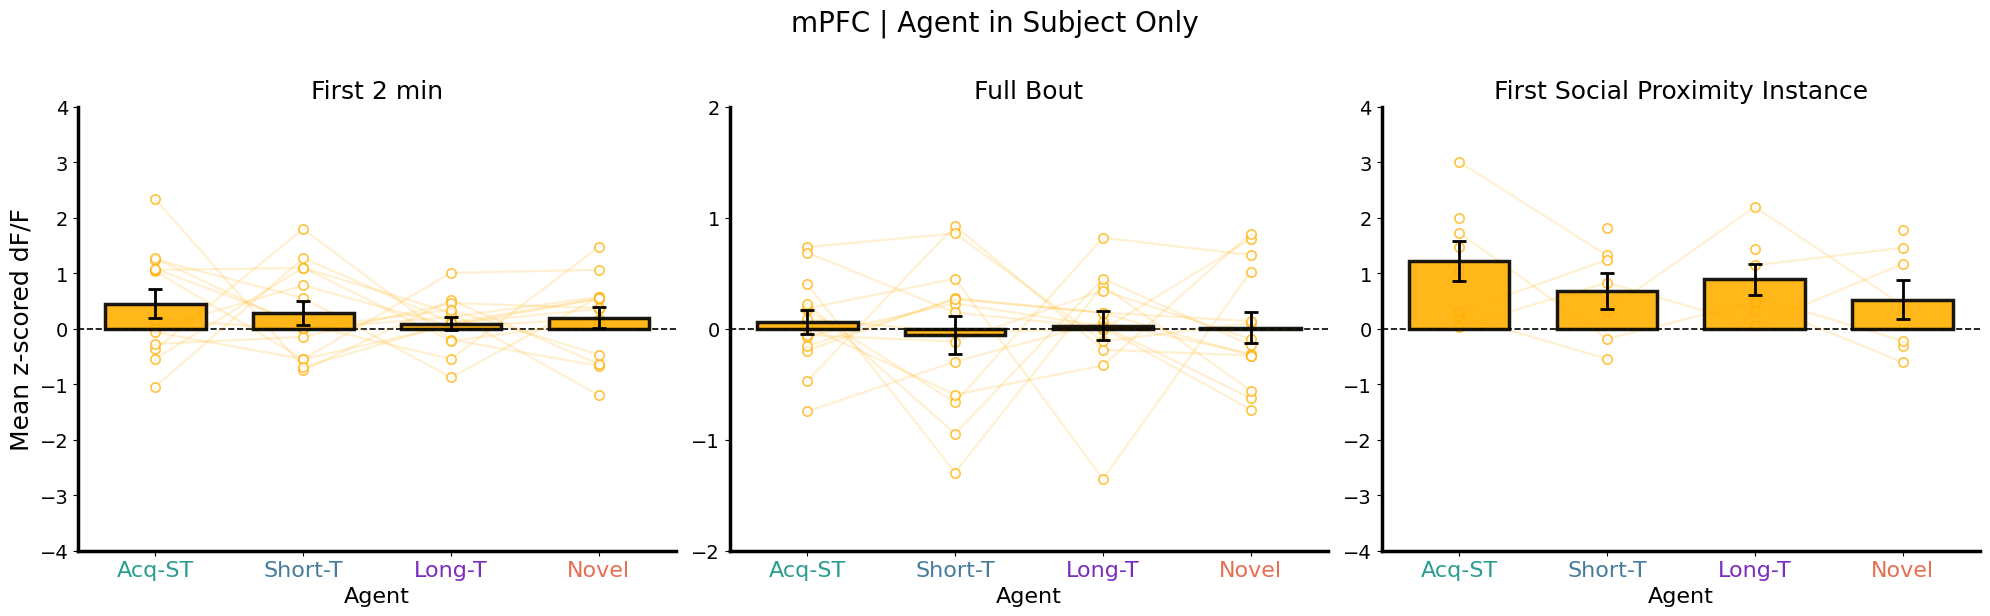

In [11]:
# 1. Any social proximity: each analysis individually, then all three together
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    for analysis_name in ANALYSIS_ORDER:
        plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='agent_in_subject_only')
    plot_all_three_analyses(metadata_df, region_name, behavior_name='agent_in_subject_only')


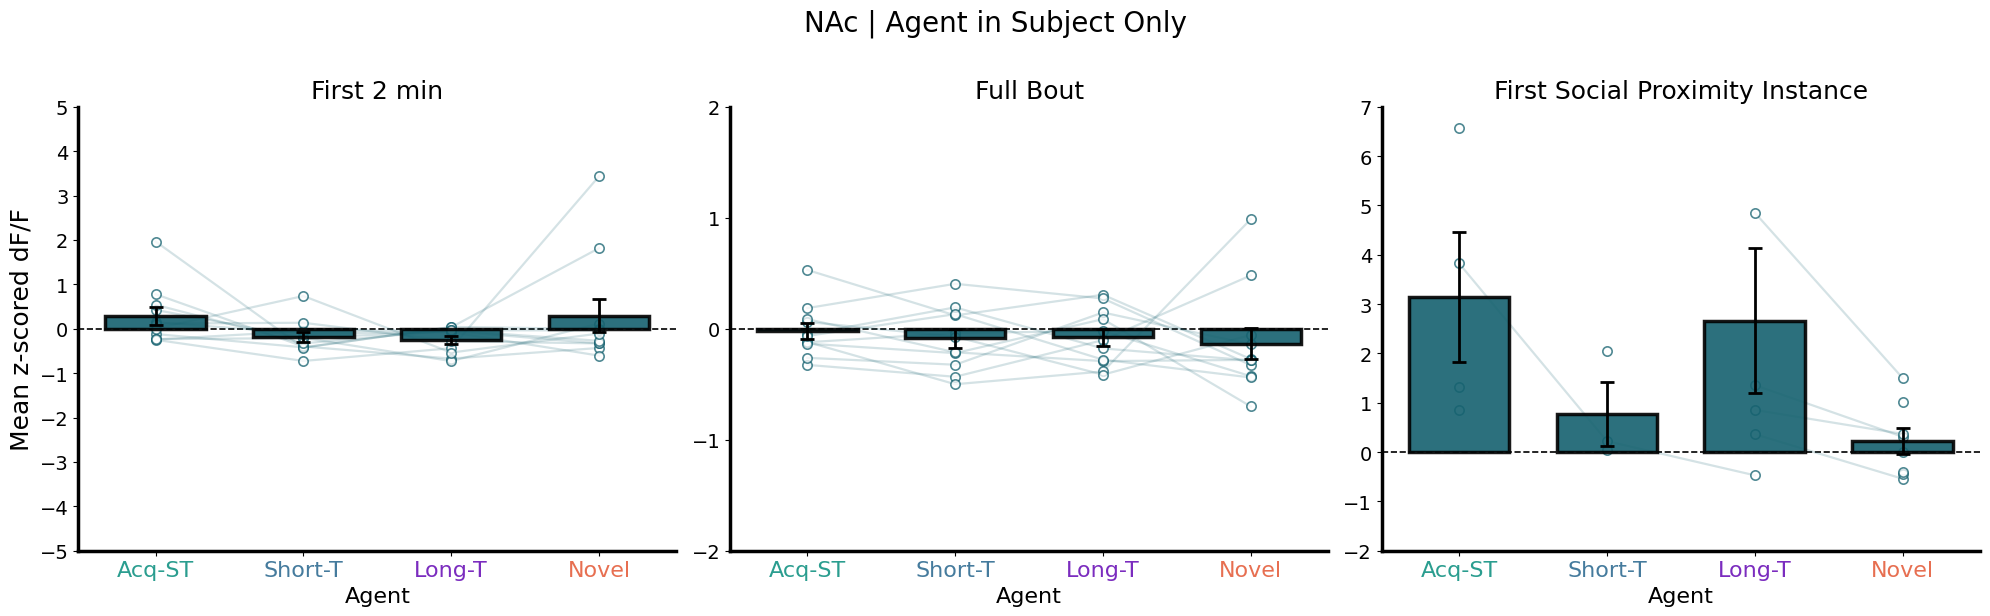

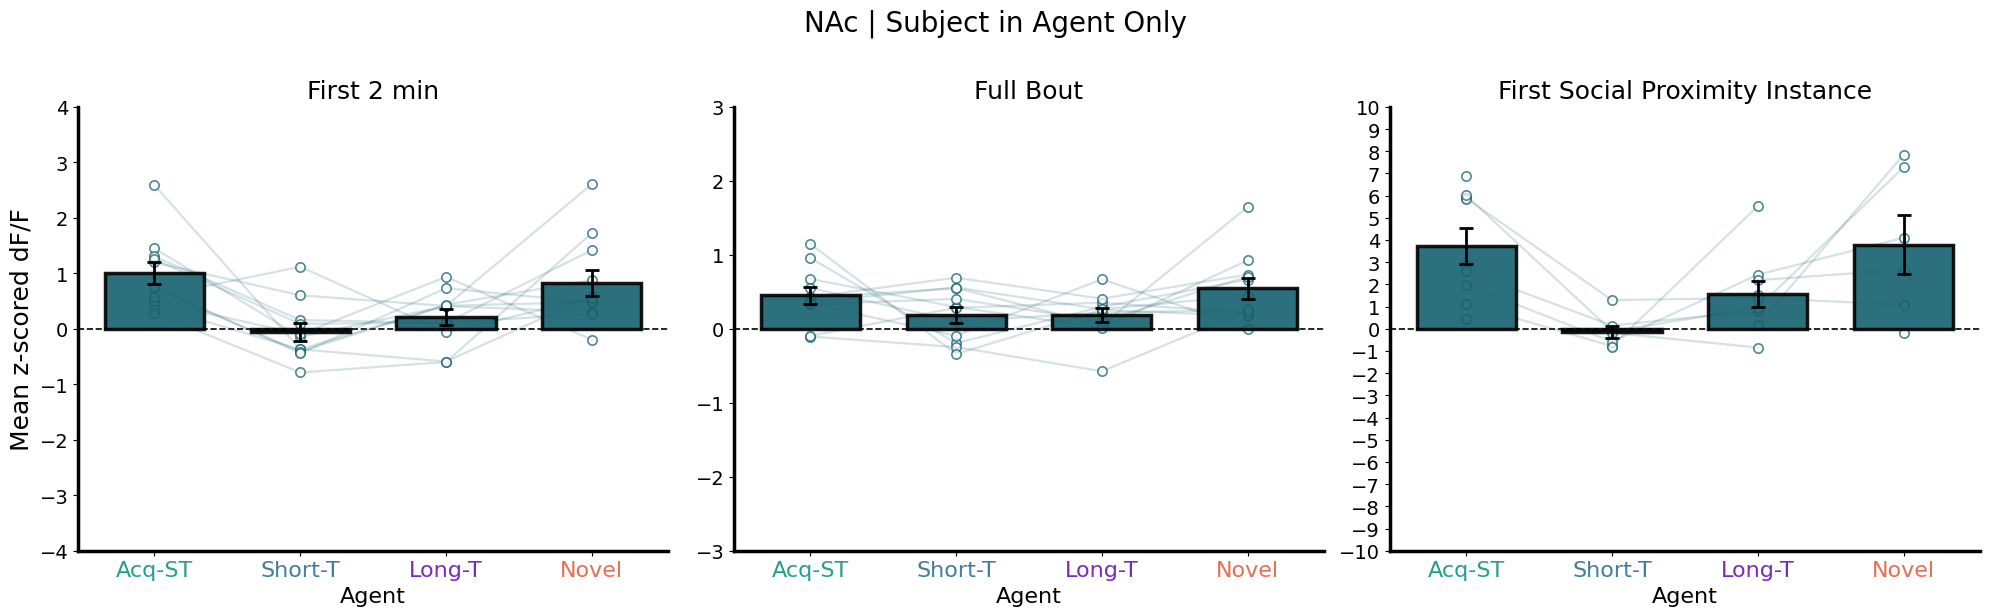

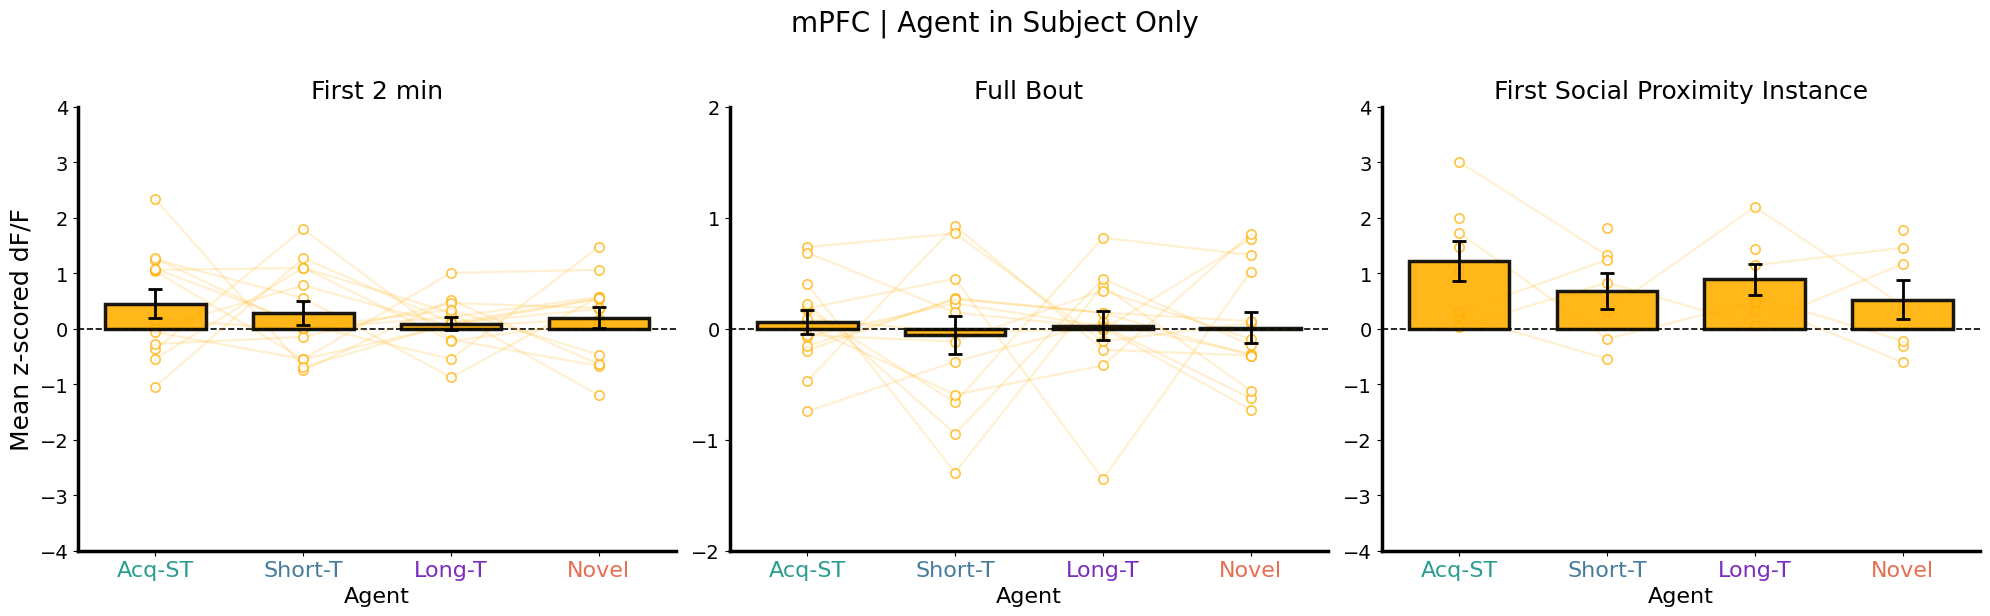

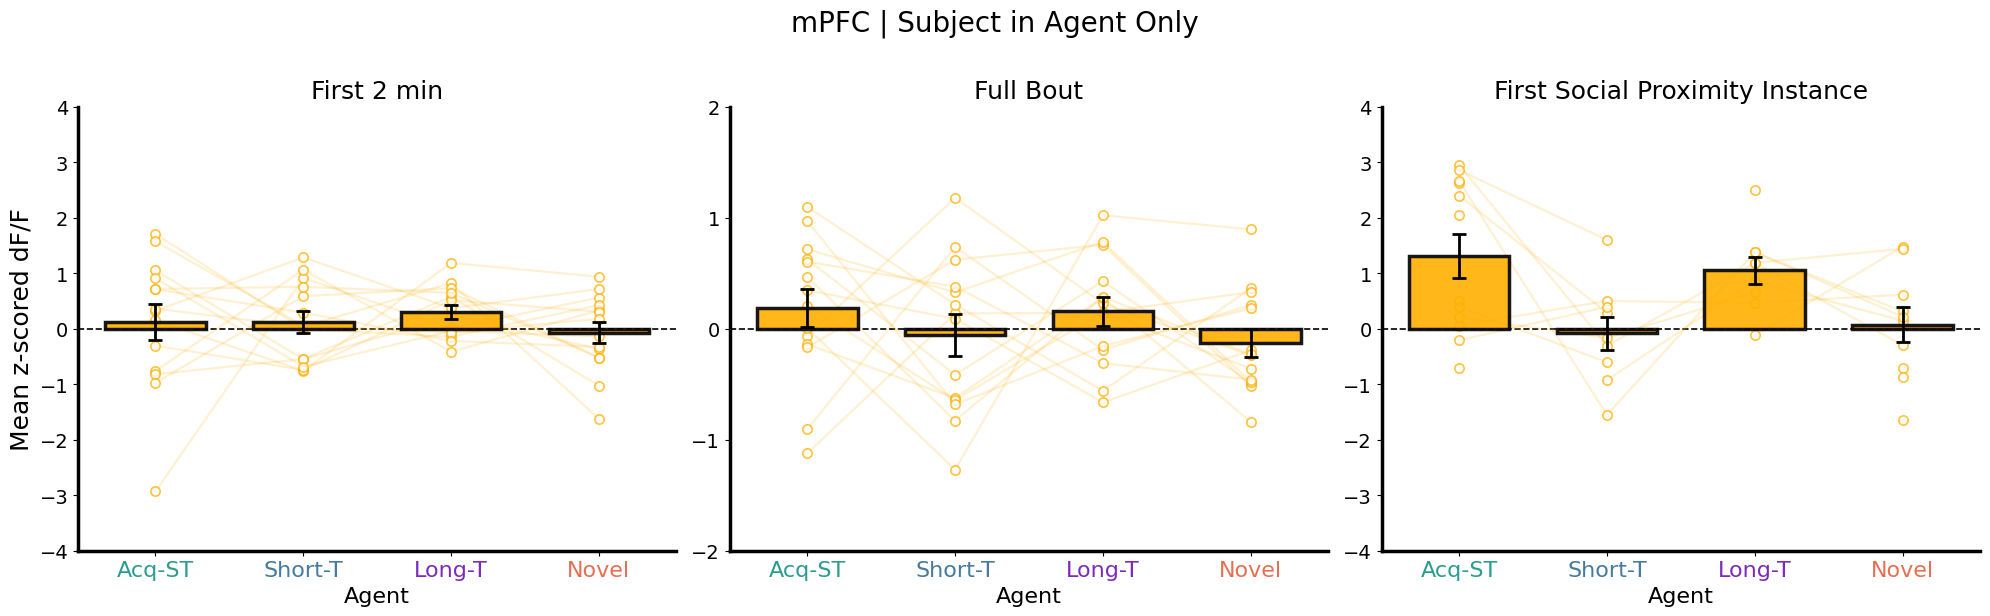

In [12]:
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_all_three_analyses(metadata_df, region_name, behavior_name='agent_in_subject_only', auto_ylim=True)
    plot_all_three_analyses(metadata_df, region_name, behavior_name='subject_in_agent_only', auto_ylim=True)

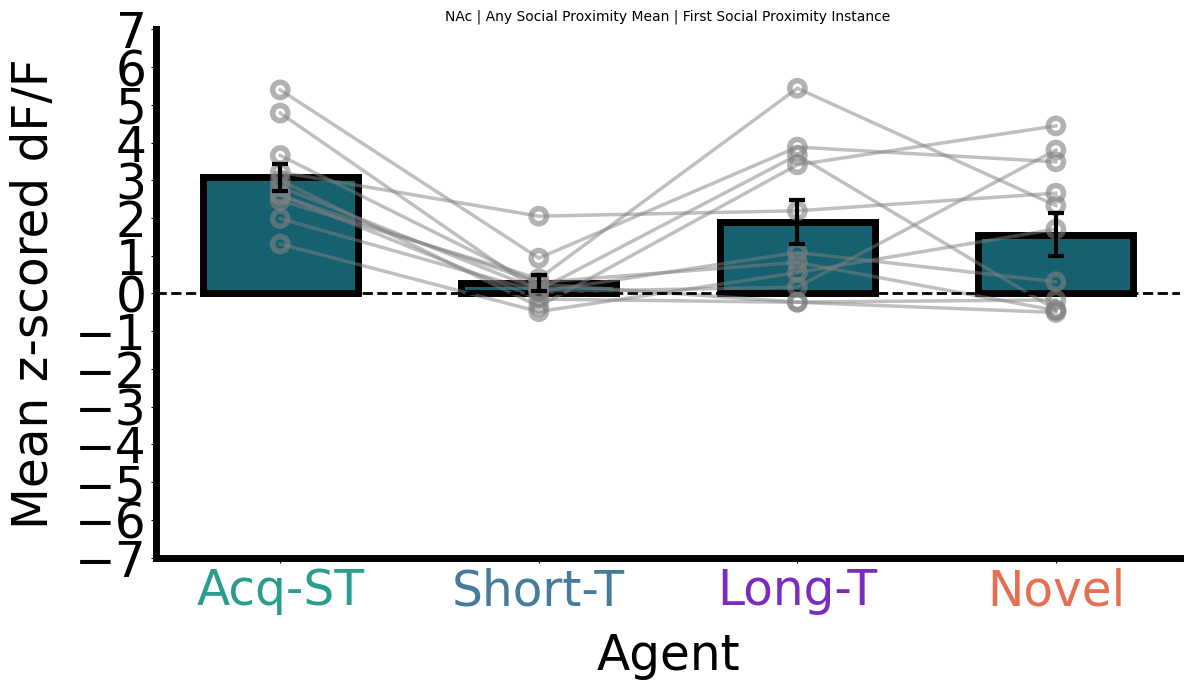


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  8.3243   0.0000   2.5099
 Short_Term-1 vs Long_Term-1 11  1.8299   0.0972   0.5517
     Short_Term-1 vs Novel-1 11  2.9518   0.0145   0.8900
 Short_Term-2 vs Long_Term-1 11 -2.8257   0.0180  -0.8520
     Short_Term-2 vs Novel-1 11 -2.2417   0.0489  -0.6759
      Long_Term-1 vs Novel-1 11  0.5183   0.6156   0.1563


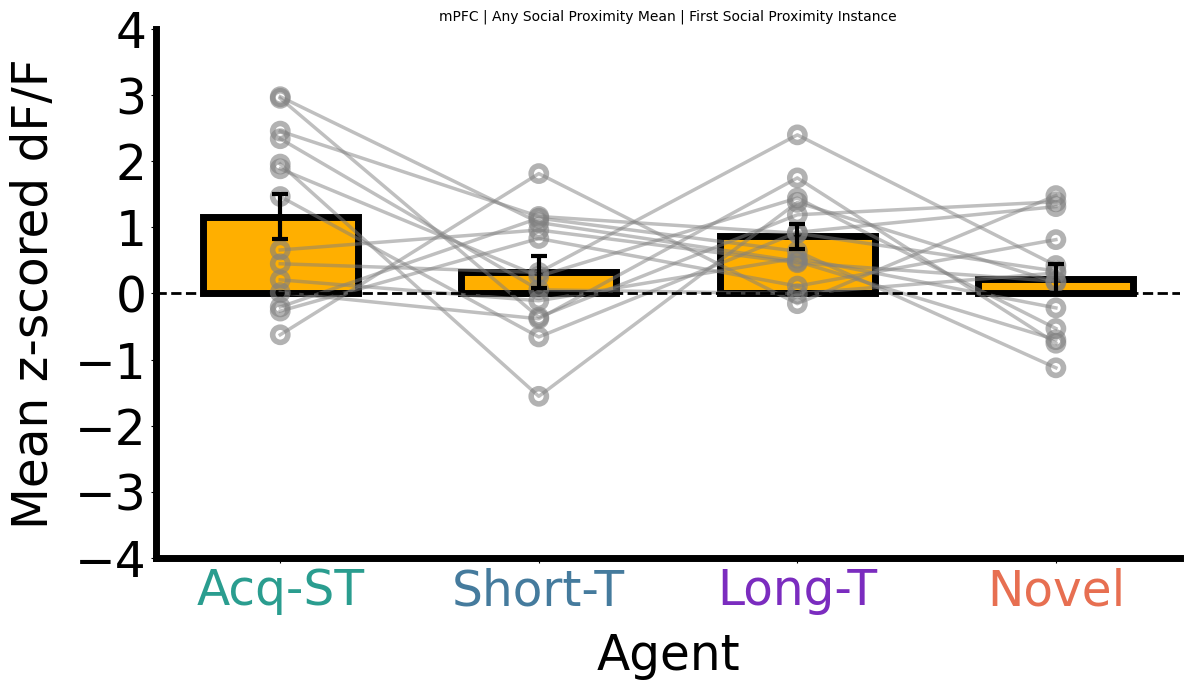


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  1.7741   0.0995   0.4741
 Short_Term-1 vs Long_Term-1 14  0.8112   0.4319   0.2168
     Short_Term-1 vs Novel-1 14  2.3696   0.0340   0.6333
 Short_Term-2 vs Long_Term-1 14 -1.4367   0.1744  -0.3840
     Short_Term-2 vs Novel-1 14  0.3112   0.7606   0.0832
      Long_Term-1 vs Novel-1 14  2.0004   0.0668   0.5346


In [13]:
# First social proximity instance regardless of who initiated
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_single_analysis(metadata_df, region_name, 'first_social_instance', behavior_name='social_any', auto_ylim=True)

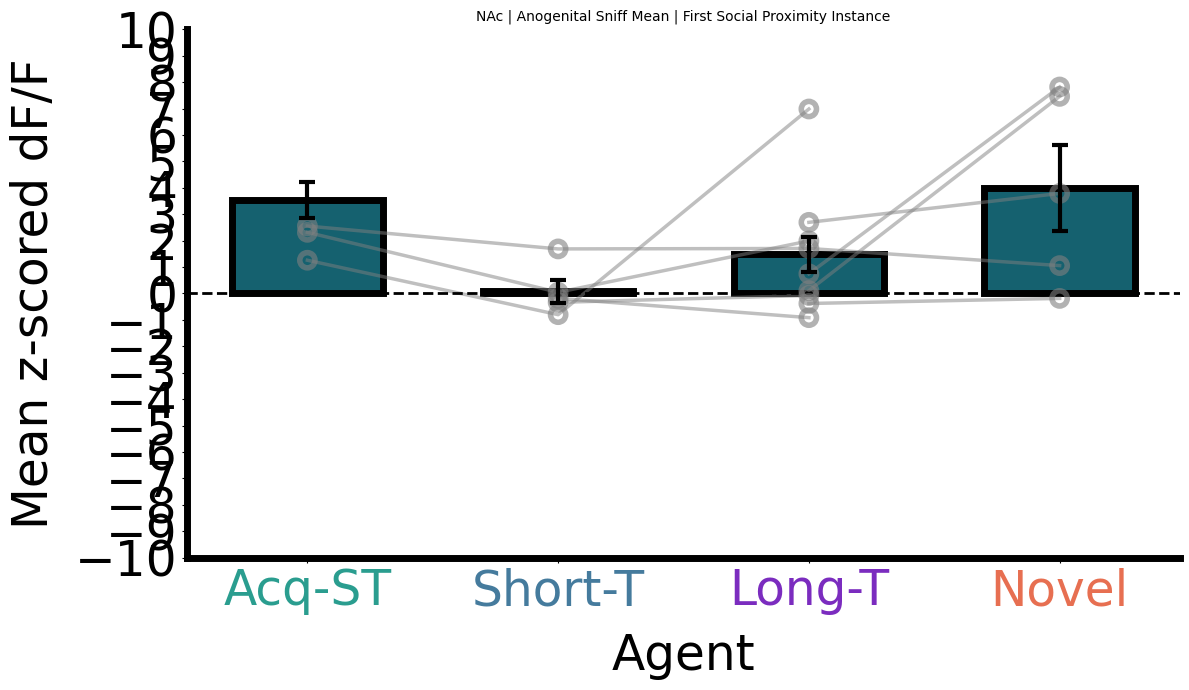


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  3  3.9624   0.0582   2.2877
 Short_Term-1 vs Long_Term-1  9  1.3646   0.2095   0.4549
     Short_Term-1 vs Novel-1  5 -0.3652   0.7334  -0.1633
 Short_Term-2 vs Long_Term-1  5 -1.2006   0.2961  -0.5369
     Short_Term-2 vs Novel-1  1     NaN      NaN      NaN
      Long_Term-1 vs Novel-1  5 -1.7343   0.1579  -0.7756


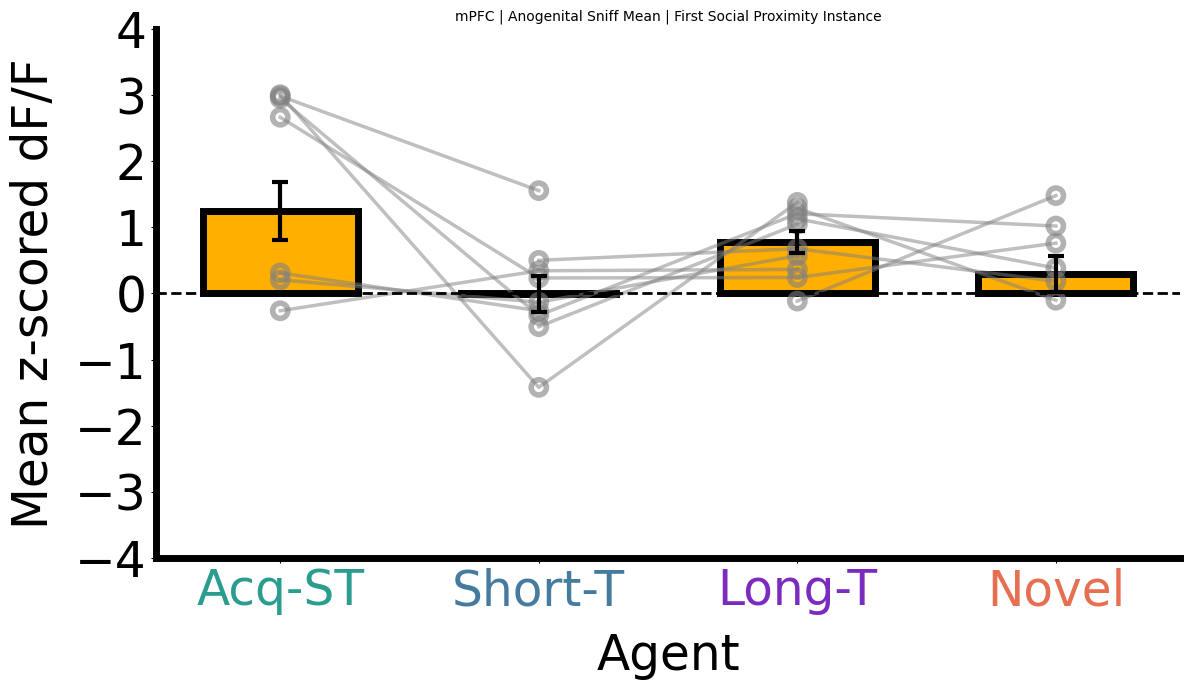


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  7  2.5236   0.0451   0.9538
 Short_Term-1 vs Long_Term-1  8  1.7711   0.1198   0.6262
     Short_Term-1 vs Novel-1  7  2.0774   0.0830   0.7852
 Short_Term-2 vs Long_Term-1  7 -2.4617   0.0490  -0.9305
     Short_Term-2 vs Novel-1  5  0.3531   0.7418   0.1579
      Long_Term-1 vs Novel-1  6  0.2735   0.7954   0.1117


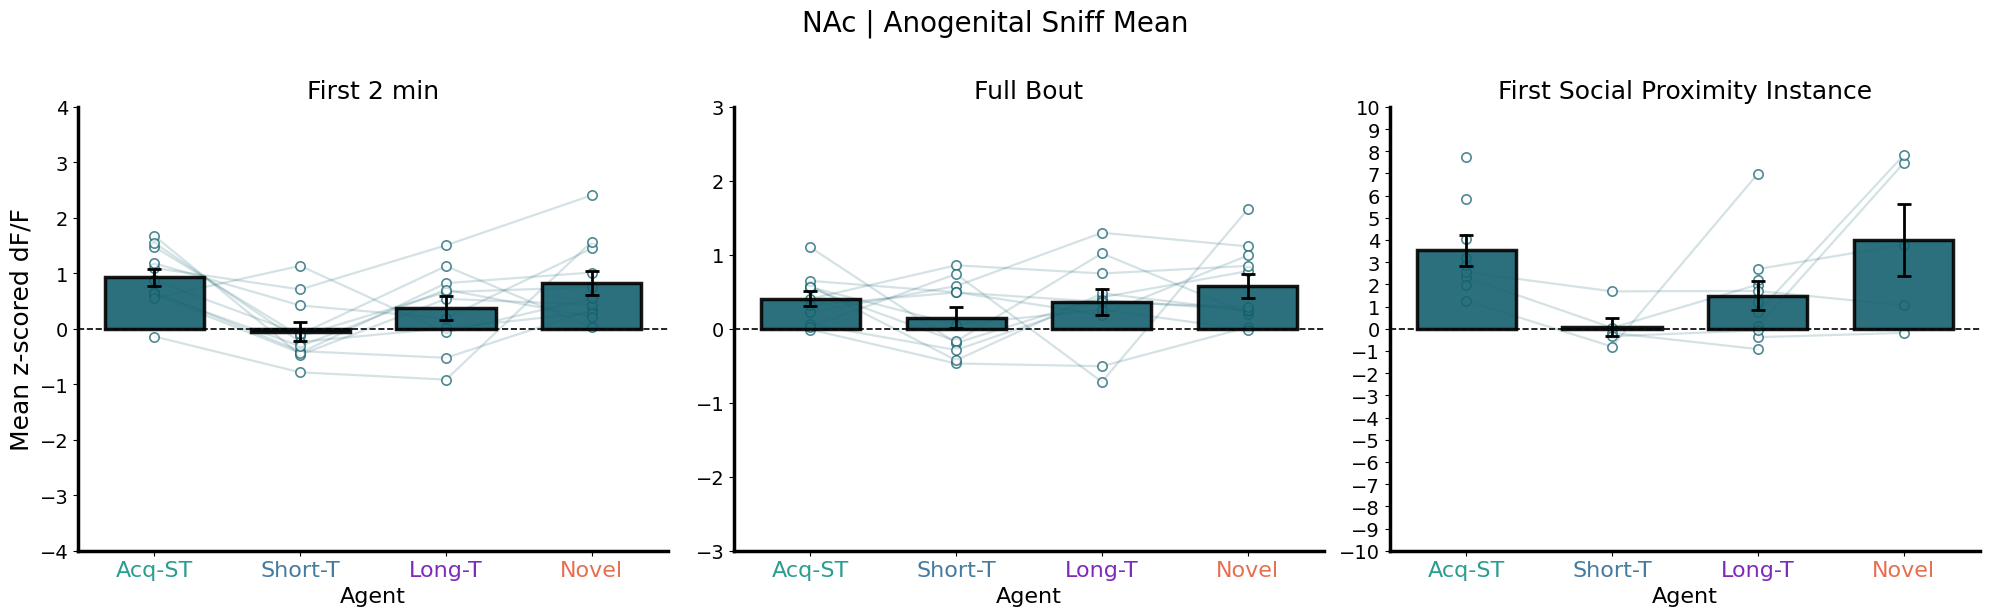

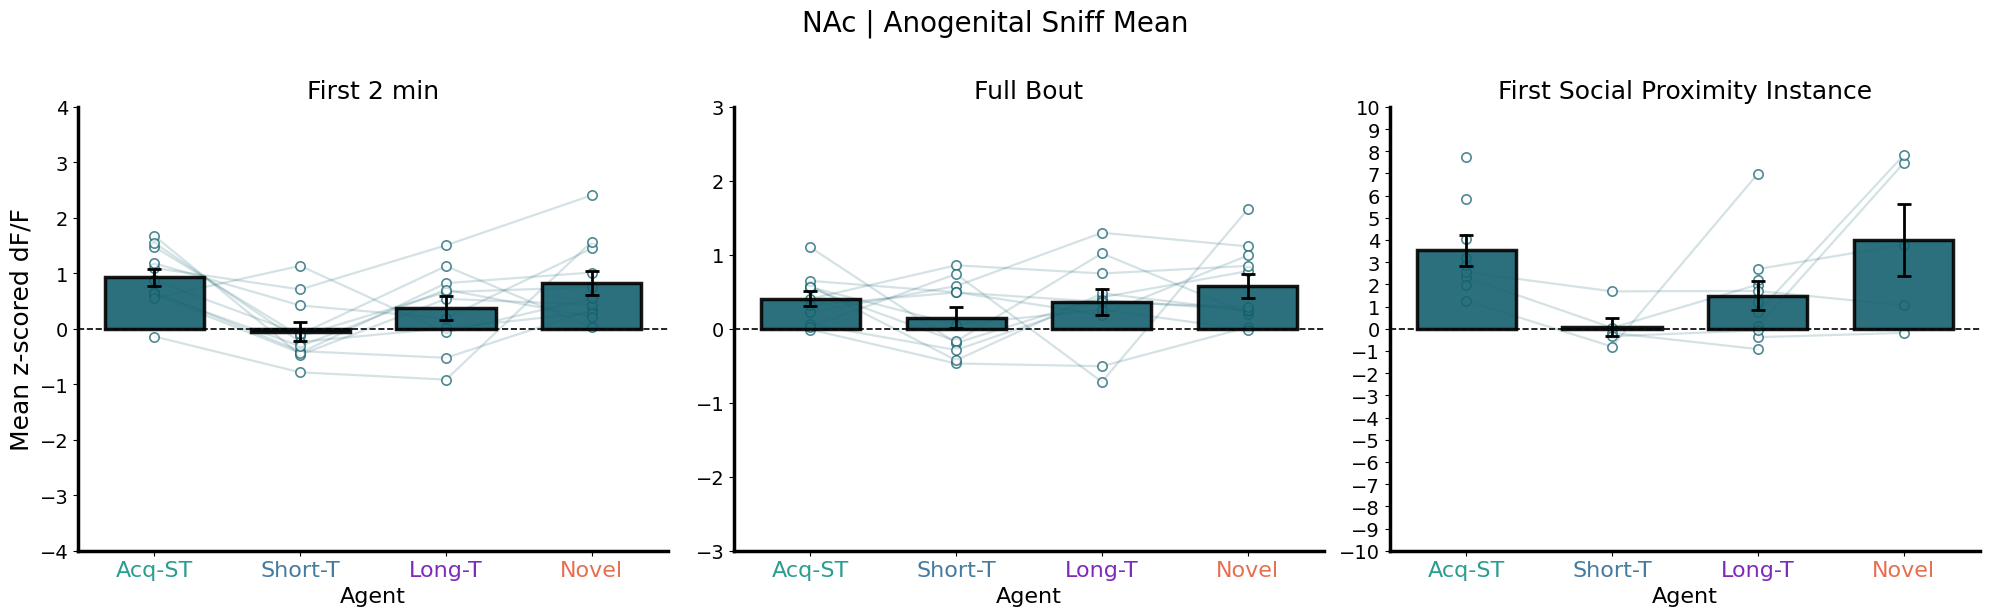

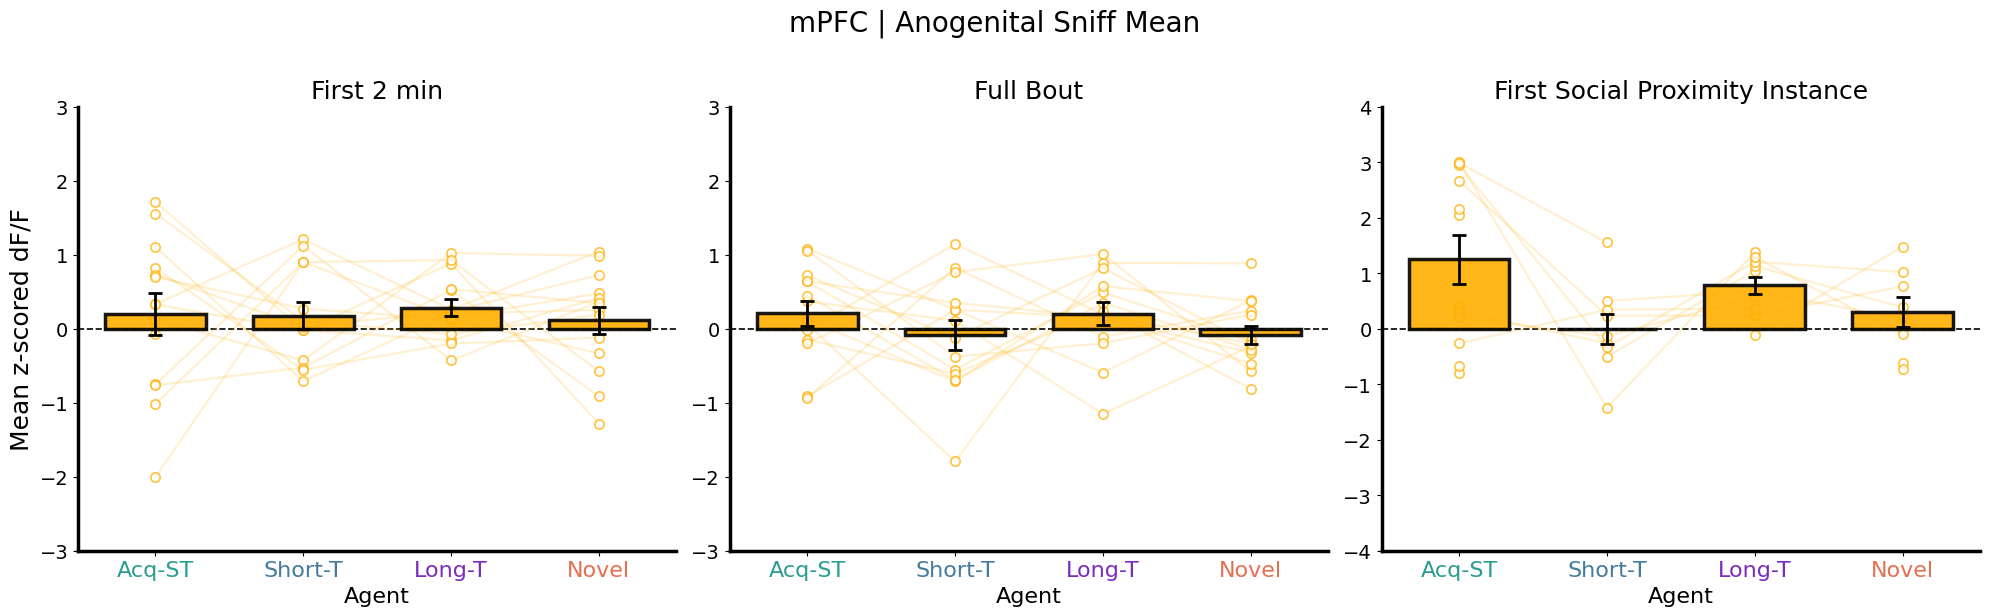

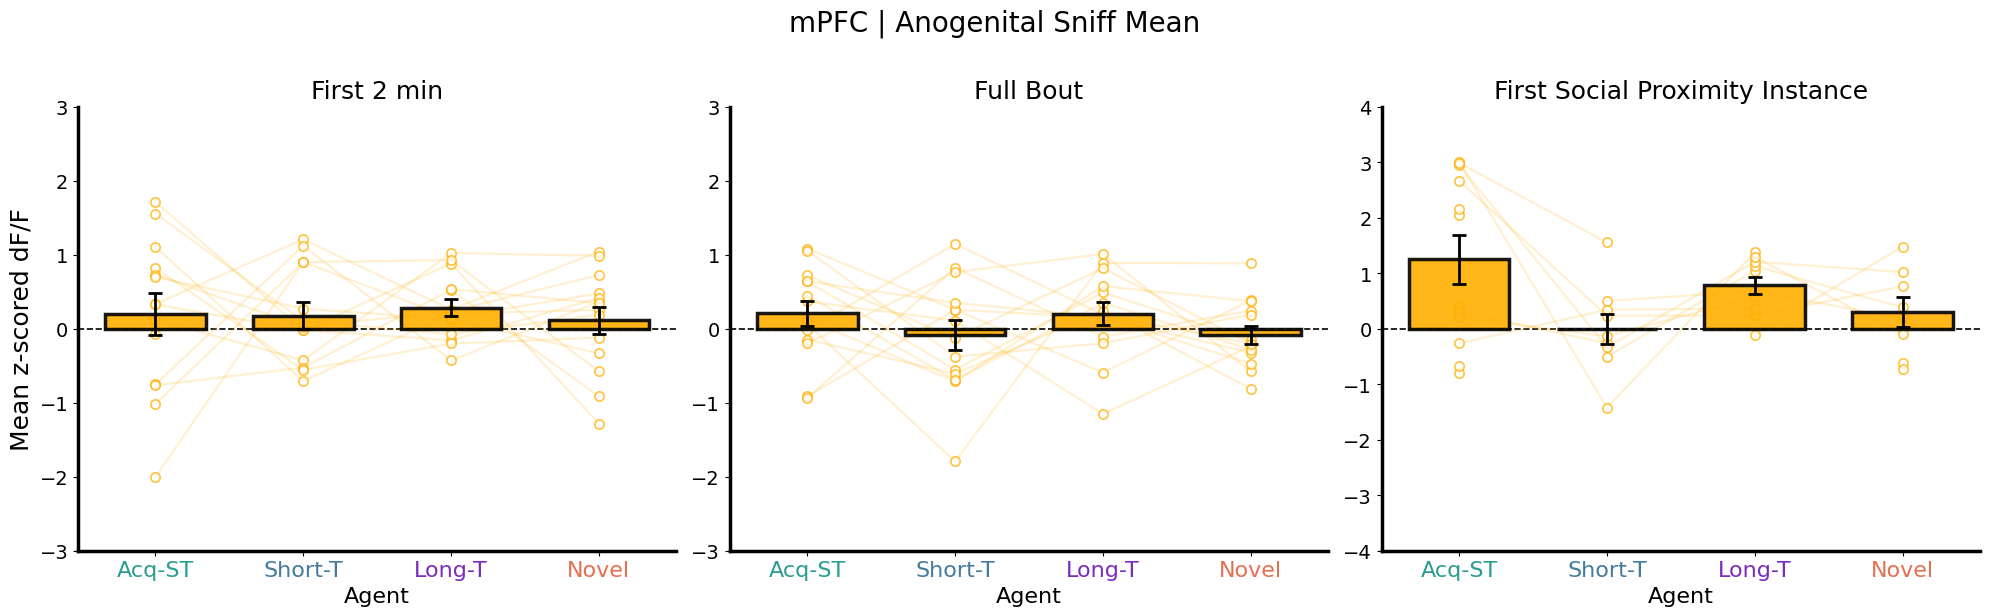

In [14]:
# First social proximity instance filtered to putative anogenital sniffing
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_single_analysis(metadata_df, region_name, 'first_social_instance', behavior_name='anogenital_sniff', auto_ylim=True)


for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_all_three_analyses(metadata_df, region_name, behavior_name='anogenital_sniff', auto_ylim=True)
    plot_all_three_analyses(metadata_df, region_name, behavior_name='anogenital_sniff', auto_ylim=True)

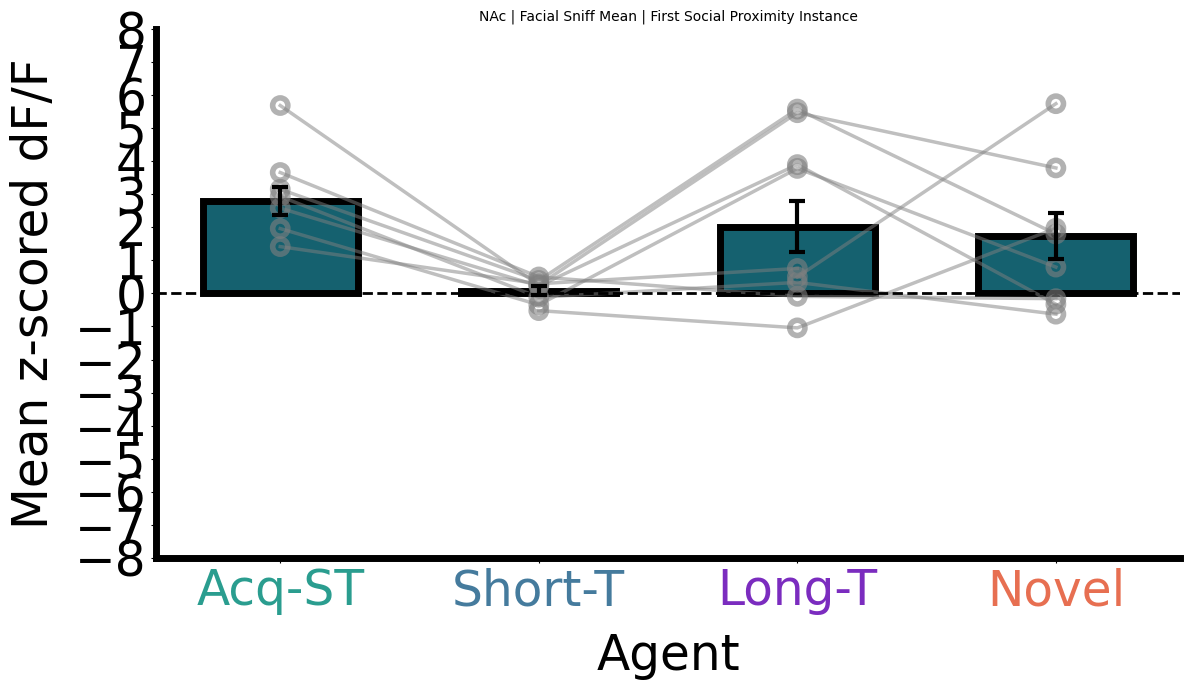


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  7  5.8198   0.0011   2.1997
 Short_Term-1 vs Long_Term-1  9  0.8103   0.4412   0.2701
     Short_Term-1 vs Novel-1  8  1.8108   0.1131   0.6402
 Short_Term-2 vs Long_Term-1  8 -2.5074   0.0406  -0.8865
     Short_Term-2 vs Novel-1  7 -1.5729   0.1668  -0.5945
      Long_Term-1 vs Novel-1  8  0.5772   0.5819   0.2041


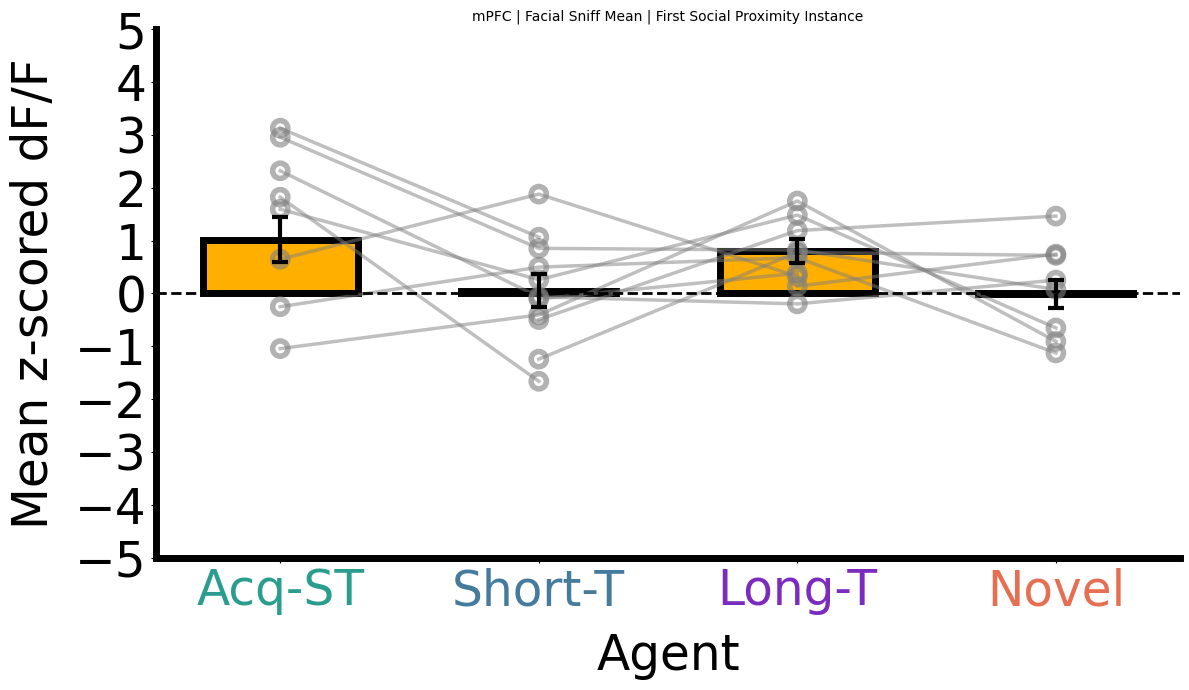


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2  8  1.7777   0.1187   0.6285
 Short_Term-1 vs Long_Term-1  9 -0.1933   0.8516  -0.0644
     Short_Term-1 vs Novel-1  8  2.7510   0.0285   0.9726
 Short_Term-2 vs Long_Term-1  9 -1.6586   0.1358  -0.5529
     Short_Term-2 vs Novel-1  9 -0.0814   0.9371  -0.0271
      Long_Term-1 vs Novel-1  8  1.6757   0.1377   0.5924


In [15]:
# First social proximity instance filtered to putative facial sniffing
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_single_analysis(metadata_df, region_name, 'first_social_instance', behavior_name='facial_sniff', auto_ylim=True)

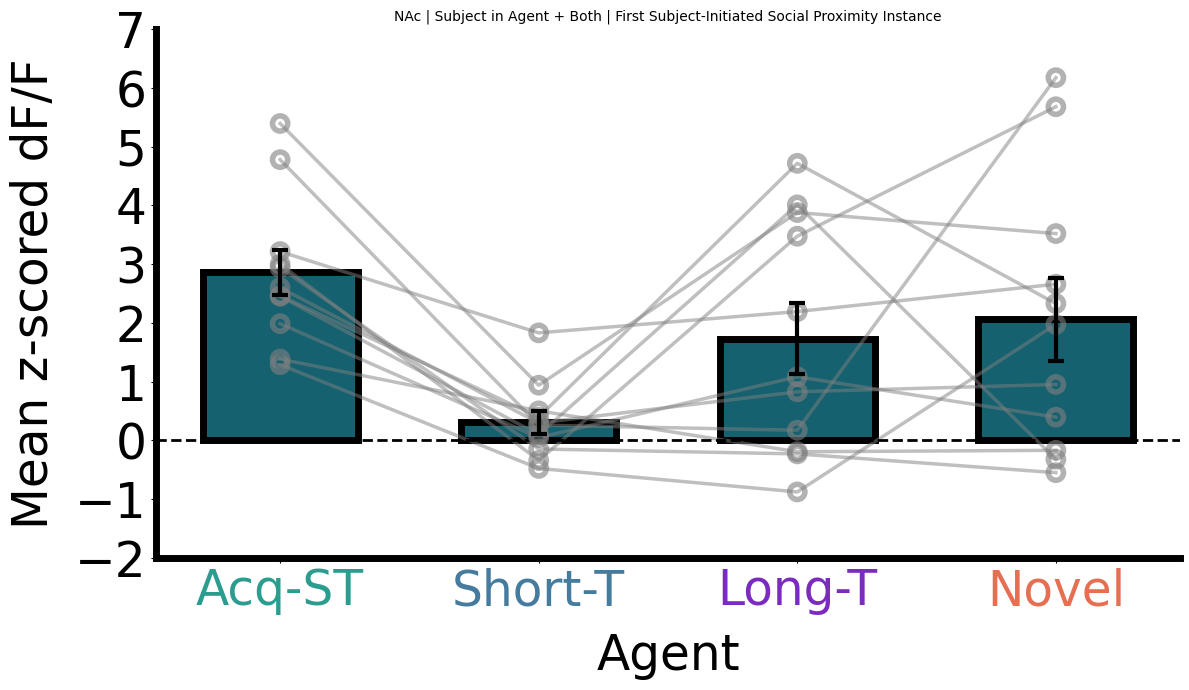


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  7.1912   0.0000   2.1682
 Short_Term-1 vs Long_Term-1 11  1.8917   0.0878   0.5704
     Short_Term-1 vs Novel-1 11  1.4523   0.1771   0.4379
 Short_Term-2 vs Long_Term-1 11 -2.4514   0.0342  -0.7391
     Short_Term-2 vs Novel-1 11 -2.4513   0.0342  -0.7391
      Long_Term-1 vs Novel-1 11 -0.4000   0.6976  -0.1206


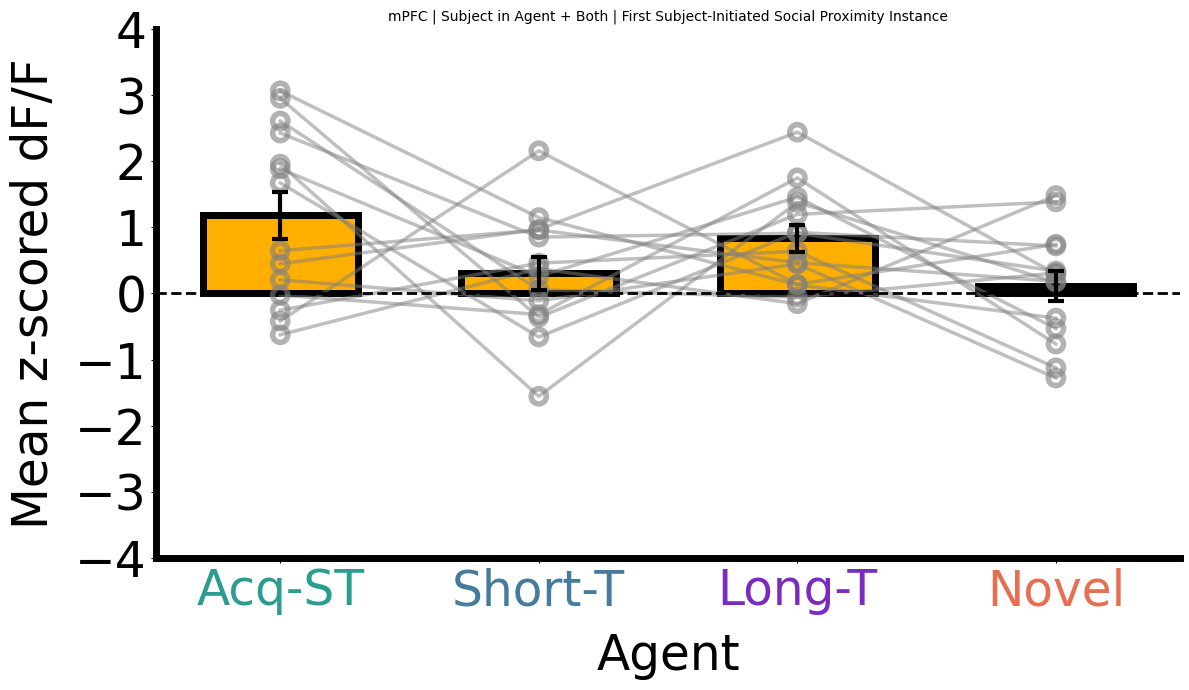


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  1.8334   0.0897   0.4900
 Short_Term-1 vs Long_Term-1 14  0.8753   0.3973   0.2339
     Short_Term-1 vs Novel-1 14  2.7637   0.0161   0.7386
 Short_Term-2 vs Long_Term-1 14 -1.4777   0.1633  -0.3949
     Short_Term-2 vs Novel-1 14  0.5918   0.5641   0.1582
      Long_Term-1 vs Novel-1 14  2.2328   0.0438   0.5967


In [16]:
# First subject-initiated social proximity instance, even if it is not the first social instance overall
MANUAL_YLIMS = {
    ('NAc', 'first_2min', 'social_any'): (-2, 2.0),
    ('NAc', 'full_bout', 'social_any'): (-2, 2),
    ('NAc', 'first_social_instance', 'social_any'): (-2, 7),
    ('NAc', 'first_subject_initiated_social_instance', 'subject_in_agent_with_both'): (-2, 7),
    ('mPFC', 'first_subject_initiated_social_instance', 'subject_in_agent_with_both'): (-4, 4),
    # ('mPFC', 'full_bout', 'subject_in_agent_only'): (-1, 1),
}
for region_name in sorted(metadata_df['BrainRegion'].dropna().unique()):
    plot_single_analysis(metadata_df, region_name, 'first_subject_initiated_social_instance', behavior_name='subject_in_agent_with_both', auto_ylim=False)